# Working Memory Architecture and Demand (WMAD) Model

The model is the result of work from the **Montbretia Cabinet** team during the Neuromatch Academy [Impact Scholars Program](https://impact-scholars.neuromatch.io/) from October 2024 to April 2025.

The Working Memory Architecture and Demand (WMAD) model is a parallel GNN-LSTM structure that feeds a Multilayer Perceptron. It was created during the Impact Scholars Program.

The WMAD model's overall structure, as seen in the image below, is constructed of a GAT, a parallel LSTM, and an MLP that uses the GAT and LSTM outputs passed through a fusion layer. This model predicts involvement of working memory in tasks in a parcel-based manner. It recieves parcel-based BOLD time series data and generates a probability value between 0 and 1 that corresponds to the likelihood of an exposure being a high-demand task. Therefore, a probability score of 1 would correspond to a high-demand task that, in the HCP data that we are using, would be the same as a 2-back working memory task.

## Setup and dependencies

In [1]:
!pip install joypy --quiet
!pip install plotly --quiet
!pip install python-louvain --quiet
!pip install torch_geometric --quiet
!pip install torchviz diagrams --quiet

import os
import re
import copy
import glob
import time
import random
import pickle
import tarfile
import requests
import warnings
import itertools

import numpy as np
import pandas as pd

import joypy
import visualkeras
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches

import networkx as nx
import community as community_louvain
import torch_geometric.utils as pyg_utils
from torch_geometric.nn import global_mean_pool
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data, DataLoader, Batch
from torch_geometric.nn import GCNConv, GATConv, GraphConv

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Layer
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from scipy.stats import zscore
from scipy.stats import ttest_ind, chi2_contingency

from IPython.display import clear_output

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
warnings.filterwarnings("ignore", category = UserWarning, module = "networkx")

2025-04-20 20:46:04.568510: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-20 20:46:04.706150: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745169364.760114    7122 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745169364.778870    7122 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745169364.890638    7122 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Parameters and Data Download
The data used for the model was shared by Neuromatch in the [Project Booklets](https://compneuro.neuromatch.io/projects/fMRI/README.html#:~:text=5%2D23%2C%202021-,HCP%20task%20datasets,-%23) and most of our data preparation is similar to what they have shared in the `load_hcp_task_with_behaviour.ipynb` in the [HCP 2021 + behavior](https://compneuro.neuromatch.io/projects/fMRI/README.html#:~:text=View-,HCP%202021%20%2B%20behavior,-HCP%202021) section.

Our target experiments (`TargetExperiments` variable below) are Working Memory, Emotion, and Language tasks.

In [2]:
N_SUBJECTS = 100
N_PARCELS  = 360 # Data aggregated into ROIs from Glasser parcellation

TR = 0.72  # Time resolution, in seconds

HEMIS  = ["Right", "Left"]
RUNS   = ["LR","RL"]
N_RUNS = 2

EXPERIMENTS = {
    "MOTOR"      : {"cond" : ["lf", "rf" ,"lh", "rh", "t", "cue"]},
    "WM"         : {"cond" : ["0bk_body", "0bk_faces", "0bk_places", "0bk_tools",
                              "2bk_body", "2bk_faces", "2bk_places", "2bk_tools"]},
    "SOCIAL"     : {"cond" : ["ment", "rnd"]},
    "GAMBLING"   : {"cond" : ["loss", "win"]},
    "EMOTION"    : {"cond" : ["fear", "neut"]},
    "LANGUAGE"   : {"cond" : ["math", "story"]},
    "RELATIONAL" : {"cond" : ["match", "relation"]}
}

TargetExperiments = ["WM", "EMOTION", "LANGUAGE"]

TargetConditions  = ["0bk_body", "0bk_faces", "0bk_places", "0bk_tools",
                     "2bk_body", "2bk_faces", "2bk_places", "2bk_tools",
                     "fear"    , "neut"     , "math"      , "story"    ]

In [3]:
fname = "hcp_task.tgz"
url = "https://osf.io/2y3fw/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("Download FAILED: Connection Error!")
  else:
    if r.status_code != requests.codes.ok:
      print("Download FAILED!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)


HCP_DIR = "./hcp_task"

with tarfile.open(fname) as tfile:
  tfile.extractall(".")

In [4]:
SubjectIDs = np.loadtxt(os.path.join(HCP_DIR, "subjects_list.txt"), dtype = "str")
SubjectIDs = list(SubjectIDs)

In [5]:
# Load region information for Glasser parcellation
regions = np.load(f"{HCP_DIR}/regions.npy").T

region_info = dict(
    name=regions[0].tolist(),
    network=regions[1],
    hemi=["Right"]*int(N_PARCELS/2) + ["Left"]*int(N_PARCELS/2),
)

In [6]:
ventral_attention_parcels    = [121, 134]

orbital_affective_parcels    = [111, 165, 289, 291, 345]

dorsal_attention_parcels     = [26, 139, 140, 206, 207, 320]

limbic_parcels               = [109, 111, 165, 289, 291, 345]

auditory_parcels             = [23, 102, 103, 123, 172, 173,
                                174, 282, 286, 287, 288, 303, 352, 353, 354]

default_mode_parcels         = [11, 24, 25, 27,
                                73, 74, 78, 80, 122, 124, 127, 128, 138, 171,
                                191, 205, 254, 258, 302, 304, 308, 318, 351]

language_parcels             = [10, 45, 49, 94,
                                95, 115, 126, 135, 136, 142, 145, 225, 229,
                                274, 275, 295, 296, 306, 315, 316, 322, 325]

frontoparietal_parcels       = [13, 14,
                                28, 62, 72, 76, 79, 81, 82, 84, 96, 97, 110,
                                132, 143, 144, 148, 169, 170, 208, 242, 252,
                                256, 259, 260, 262, 264, 276, 277, 290, 298]

somatomotor_parcels          = [7, 8, 35, 38, 39, 40, 41, 46,
                                50, 51, 52, 53, 54, 55, 99, 100, 101, 167,
                                187, 188, 215, 218, 219, 220, 221, 226, 230,
                                231, 232, 233, 234, 235, 279, 280, 281, 347]

cingulo_opercular_parcels    = [9, 36, 37, 42, 43, 44, 56, 57, 58, 59, 98,
                                104, 105, 107, 112, 113, 114, 116, 178, 179,
                                189, 190, 204, 216, 217, 222, 223, 224, 236,
                                237, 238, 239, 257, 261, 263, 265, 275, 277,
                                285, 292, 293, 346, 348, 357, 358, 359]

visual_parcels               = [0, 1, 2, 3, 4, 5, 6,
                                12, 15, 16, 17, 18, 19, 20, 21, 22, 47, 48,
                                137, 141, 151, 152, 153, 155, 156, 157, 158,
                                159, 162, 186, 192, 195, 196, 197, 198, 199,
                                200, 201, 202, 227, 228, 317, 321, 331, 332,
                                333, 335, 336, 337, 338, 339, 342]

posterior_multimodal_parcels = [29, 30, 31, 32, 33, 34, 60, 61, 63, 64, 65,
                                66, 67, 68, 69, 70, 71, 75, 86, 87, 88, 89,
                                117, 118, 119, 130, 131, 133, 154, 160, 161,
                                163, 164, 175, 176, 177, 180, 181, 182, 183,
                                184, 185, 192, 193, 194, 195, 196, 197, 198,
                                199, 200, 201, 202, 214, 215, 216, 217, 218,
                                219, 220, 221, 230, 231, 232, 233, 234, 235,
                                246, 247, 248, 249, 250, 251, 252, 253, 255,
                                266, 267, 269, 270, 271, 272, 273, 276, 277,
                                278, 279, 280, 281, 283, 284, 297, 299, 300,
                                301, 305, 307, 309, 310, 311, 312, 313, 314,
                                319, 323, 324, 326, 327, 328, 329, 330, 341,
                                344, 349, 350]

# Dictionary of subnetworks with no. of parcels and the list of corresponding parcels.
subnetworks = {
    f"visual_nw_{len(visual_parcels)}"                             : visual_parcels             ,
    f"limbic_nw_{len(limbic_parcels)}"                             : limbic_parcels             ,
    f"auditory_nw_{len(auditory_parcels)}"                         : auditory_parcels           ,
    f"language_nw_{len(language_parcels)}"                         : language_parcels           ,
    f"somatomotor_nw_{len(somatomotor_parcels)}"                   : somatomotor_parcels        ,
    f"default_mode_nw_{len(default_mode_parcels)}"                 : default_mode_parcels       ,
    f"frontoparietal_nw_{len(frontoparietal_parcels)}"             : frontoparietal_parcels     ,
    f"dorsal_attention_nw_{len(dorsal_attention_parcels)}"         : dorsal_attention_parcels   ,
    f"cingulo_opercular_nw_{len(cingulo_opercular_parcels)}"       : cingulo_opercular_parcels  ,
    f"orbital_affective_nw_{len(orbital_affective_parcels)}"       : orbital_affective_parcels  ,
    f"ventral_attention_nw_{len(ventral_attention_parcels)}"       : ventral_attention_parcels  ,
    f"posterior_multimodal_nw_{len(posterior_multimodal_parcels)}" : posterior_multimodal_parcels
}

In [7]:
#Glasser Parcel Label Dictionary
Glasser_parcels_labels = ({
      0: "V1_L"    ,   1: "V1_R"    ,   2: "V2_L"    ,   3: "V2_R"    ,   4: "V3_L"    ,   5: "V3_R"    ,
      6: "V4_L"    ,   7: "V4_R"    ,   8: "V3A_L"   ,   9: "V3A_R"   ,  10: "V3B_L"   ,  11: "V3B_R"   ,
     12: "V6_L"    ,  13: "V6_R"    ,  14: "V6A_L"   ,  15: "V6A_R"   ,  16: "V7_L"    ,  17: "V7_R"    ,
     18: "V8_L"    ,  19: "V8_R"    ,  20: "IPS1_L"  ,  21: "IPS1_R"  ,  22: "MST_L"   ,  23: "MST_R"   ,
     24: "LO1_L"   ,  25: "LO1_R"   ,  26: "LO2_L"   ,  27: "LO2_R"   ,  28: "MT_L"    ,  29: "MT_R"    ,
     30: "V3CD_L"  ,  31: "V3CD_R"  ,  32: "PHC1_L"  ,  33: "PHC1_R"  ,  34: "PHC2_L"  ,  35: "PHC2_R"  ,
     36: "FFC_L"   ,  37: "FFC_R"   ,  38: "PIT_L"   ,  39: "PIT_R"   ,  40: "VVC_L"   ,  41: "VVC_R"   ,
     42: "IT_L"    ,  43: "IT_R"    ,  44: "TPOJ1_L" ,  45: "TPOJ1_R" ,  46: "TPOJ2_L" ,  47: "TPOJ2_R" ,
     48: "TPOJ3_L" ,  49: "TPOJ3_R" ,  50: "STSdp_L" ,  51: "STSdp_R" ,  52: "STSvp_L" ,  53: "STSvp_R" ,
     54: "STSva_L" ,  55: "STSva_R" ,  56: "FEF_L"   ,  57: "FEF_R"   ,  58: "PEF_L"   ,  59: "PEF_R"   ,
     60: "AIP_L"   ,  61: "AIP_R"   ,  62: "VIP_L"   ,  63: "VIP_R"   ,  64: "LIPd_L"  ,  65: "LIPd_R"  ,
     66: "LIPv_L"  ,  67: "LIPv_R"  ,  68: "MIP_L"   ,  69: "MIP_R"   ,  70: "V6_L"    ,  71: "V6_R"    ,
     72: "V6A_L"   ,  73: "V6A_R"   ,  74: "V7_L"    ,  75: "V7_R"    ,  76: "V8_L"    ,  77: "V8_R"    ,
     78: "PHT_L"   ,  79: "PHT_R"   ,  80: "PIT_L"   ,  81: "PIT_R"   ,  82: "TPOJ1_L" ,  83: "TPOJ1_R" ,
     84: "TPOJ2_L" ,  85: "TPOJ2_R" ,  86: "TPOJ3_L" ,  87: "TPOJ3_R" ,  88: "STSdp_L" ,  89: "STSdp_R" ,
     90: "STSvp_L" ,  91: "STSvp_R" ,  92: "STSva_L" ,  93: "STSva_R" ,  94: "TE1p_L"  ,  95: "TE1p_R"  ,
     96: "TE1a_L"  ,  97: "TE1a_R"  ,  98: "TE2p_L"  ,  99: "TE2p_R"  , 100: "TE2a_L"  , 101: "TE2a_R"  ,
    102: "TGd_L"   , 103: "TGd_R"   , 104: "Tg1_L"   , 105: "Tg1_R"   , 106: "Tg2_L"   , 107: "Tg2_R"   ,
    108: "FST_L"   , 109: "FST_R"   , 110: "MTGd_L"  , 111: "MTGd_R"  , 112: "MTGv_L"  , 113: "MTGv_R"  ,
    114: "PHT_L"   , 115: "PHT_R"   , 116: "PIT_L"   , 117: "PIT_R"   , 118: "TF_L"    , 119: "TF_R"    ,
    120: "MST_L"   , 121: "MST_R"   , 122: "STV_L"   , 123: "STV_R"   , 124: "VVC_L"   , 125: "VVC_R"   ,
    126: "PHC1_L"  , 127: "PHC1_R"  , 128: "PHC2_L"  , 129: "PHC2_R"  , 130: "RSC_L"   , 131: "RSC_R"   ,
    132: "POS1_L"  , 133: "POS1_R"  , 134: "POS2_L"  , 135: "POS2_R"  , 136: "POS3_L"  , 137: "POS3_R"  ,
    138: "DVT_L"   , 139: "DVT_R"   , 140: "VCC_L"   , 141: "VCC_R"   , 142: "PCC_L"   , 143: "PCC_R"   ,
    144: "MCC_L"   , 145: "MCC_R"   , 146: "SCC_L"   , 147: "SCC_R"   , 148: "ACC_L"   , 149: "ACC_R"   ,
    150: "OFC_L"   , 151: "OFC_R"   , 152: "p32_L"   , 153: "p32_R"   , 154: "a32pr_L" , 155: "a32pr_R" ,
    156: "a32_L"   , 157: "a32_R"   , 158: "p24pr_L" , 159: "p24pr_R" , 160: "p24_L"   , 161: "p24_R"   ,
    162: "a24pr_L" , 163: "a24pr_R" , 164: "a24_L"   , 165: "a24_R"   , 166: "s32_L"   , 167: "s32_R"   ,
    168: "d32_L"   , 169: "d32_R"   , 170: "p10p_L"  , 171: "p10p_R"  , 172: "10v_L"   , 173: "10v_R"   ,
    174: "10d_L"   , 175: "10d_R"   , 176: "9m_L"    , 177: "9m_R"    , 178: "9p_L"    , 179: "9p_R"    ,
    180: "8m_L"    , 181: "8m_R"    , 182: "8d_L"    , 183: "8d_R"    , 184: "8v_L"    , 185: "8v_R"    ,
    186: "p10r_L"  , 187: "p10r_R"  , 188: "a10p_L"  , 189: "a10p_R"  , 190: "a10r_L"  , 191: "a10r_R"  ,
    192: "47m_L"   , 193: "47m_R"   , 194: "47s_L"   , 195: "47s_R"   , 196: "45_L"    , 197: "45_R"    ,
    198: "44_L"    , 199: "44_R"    , 200: "p9-46v_L", 201: "p9-46v_R", 202: "a9-46v_L", 203: "a9-46v_R",
    204: "p9-46d_L", 205: "p9-46d_R", 206: "a9-46d_L", 207: "a9-46d_R", 208: "p8-46v_L", 209: "p8-46v_R",
    210: "a8-46v_L", 211: "a8-46v_R", 212: "8B_L"    , 213: "8B_R"    , 214: "s6-8_L"  , 215: "s6-8_R"  ,
    216: "6v_L"    , 217: "6v_R"    , 218: "6d_L"    , 219: "6d_R"    , 220: "6a_L"    , 221: "6a_R"    ,
    222: "6mp_L"   , 223: "6mp_R"   , 224: "6ma_L"   , 225: "6ma_R"   , 226: "SPL1_L"  , 227: "SPL1_R"  , 
    228: "7Pm_L"   , 229: "7Pm_R"   , 230: "7Am_L"   , 231: "7Am_R"   , 232: "7PL_L"   , 233: "7PL_R"   ,
    234: "7AL_L"   , 235: "7AL_R"   , 236: "LIPv_L"  , 237: "LIPv_R"  , 238: "VIP_L"   , 239: "VIP_R"   ,
    240: "AIP_L"   , 241: "AIP_R"   , 242: "MIP_L"   , 243: "MIP_R"   , 244: "PEF_L"   , 245: "PEF_R"   ,
    246: "FEF_L"   , 247: "FEF_R"   , 248: "IFJ_L"   , 249: "IFJ_R"   , 250: "A4_L"    , 251: "A4_R"    ,
    252: "OP4_L"   , 253: "OP4_R"   , 254: "OP1_L"   , 255: "OP1_R"   , 256: "OP2-3_L" , 257: "OP2-3_R" ,
    258: "RI_L"    , 259: "RI_R"    , 260: "POS1_L"  , 261: "POS1_R"  , 262: "DVT_L"   , 263: "DVT_R"   ,
    264: "PGp_L"   , 265: "PGp_R"   , 266: "V3CD_L"  , 267: "V3CD_R"  , 268: "31pd_L"  , 269: "31pd_R"  ,
    270: "31pv_L"  , 271: "31pv_R"  , 272: "31a_L"   , 273: "31a_R"   , 274: "23d_L"   , 275: "23d_R"   ,
    276: "v23ab_L" , 277: "v23ab_R" , 278: "d23ab_L" , 279: "d23ab_R" , 280: "8C_L"    , 281: "8C_R"    ,
    282: "p32pr_L" , 283: "p32pr_R" , 284: "a32pr_L" , 285: "a32pr_R" , 286: "p32_L"   , 287: "p32_R"   ,
    288: "s32_L"   , 289: "s32_R"   , 290: "8BM_L"   , 291: "8BM_R"   , 292: "10d_L"   , 293: "10d_R"   , 
    294: "10v_L"   , 295: "10v_R"   , 296: "47m_L"   , 297: "47m_R"   , 298: "a47r_L"  , 299: "a47r_R"  ,
    300: "11l_L"   , 301: "11l_R"   , 302: "13l_L"   , 303: "13l_R"   , 304: "a24_L"   , 305: "a24_R"   ,
    306: "p24_L"   , 307: "p24_R"   , 308: "33pr_L"  , 309: "33pr_R"  , 310: "a24pr_L" , 311: "a24pr_R" ,
    312: "p24pr_L" , 313: "p24pr_R" , 314: "8Av_L"   , 315: "8Av_R"   , 316: "9m_L"    , 317: "9m_R"    ,
    318: "9p_L"    , 319: "9p_R"    , 320: "10pp_L"  , 321: "10pp_R"  , 322: "a9-46v_L", 323: "a9-46v_R",
    324: "46_L"    , 325: "46_R"    , 326: "i6-8_L"  , 327: "i6-8_R"  , 328: "s6-8_L"  , 329: "s6-8_R"  ,
    330: "a9-46d_L", 331: "a9-46d_R", 332: "p9-46v_L", 333: "p9-46v_R", 334: "p9-46d_L", 335: "p9-46d_R",
    336: "8Ad_L"   , 337: "8Ad_R"   , 338: "8B_L"    , 339: "8B_R"    , 340: "p10p_L"  , 341: "p10p_R"  ,
    342: "10r_L"   , 343: "10r_R"   , 344: "47s_L"   , 345: "47s_R"   , 346: "a47_L"   , 347: "a47_R"   ,
    348: "11m_L"   , 349: "11m_R"   , 350: "13m_L"   , 351: "13m_R"   , 352: "OFC_L"   , 353: "OFC_R"   ,
    354: "47l_L"   , 355: "47l_R"   , 356: "LIM_L"   , 357: "LIM_R"   , 358: "13b_L"   , 359: "13b_R"
})

## Preprocessing

### Preprocessing helper functions

#### Functions for extracting the data

In [8]:
def load_single_timeseries(subject, experiment, run, remove_mean = True):
    """Loads timeseries data for a single subject and single run.

    Arguments:
        subject      (str): Subject ID to load
        experiment   (str): Name of experiment ("WM", "EMOTION", "LANGUAGE", etc.)
        run          (int): Run index (0 or 1)
        remove_mean (bool): If True, the parcel-wise mean will be subtracted

    Returns:
        np.ndarray: Array of BOLD data values with shape (n_parcels x n_timepoints)
    """
    bold_run  = RUNS[run]
    bold_path = f"{HCP_DIR}/subjects/{subject}/{experiment}/tfMRI_{experiment}_{bold_run}"
    ts_path   = f"{bold_path}/data.npy"
    
    if not os.path.exists(ts_path):
        raise FileNotFoundError(f"Timeseries file not found: {ts_path}")
    ts = np.load(ts_path)
    
    if remove_mean:
        ts = ts - ts.mean(axis=1, keepdims=True)  # Normalize by removing mean signal
    return ts

In [9]:
def load_evs_as_dict(subject, experiment, run):
    """Loads Explanatory Variables (EVs) data for one task experiment.

    Arguments:
        subject    (str): Subject ID
        experiment (str): Experiment name
        run        (int): Run index (0 or 1)
    
    Returns:
        dict: Dictionary containing EV data for each task condition
    """
    
    # Ensure "run" is an index, not a string like "LR"
    if isinstance(run, str):
        if run in RUNS:
            run = RUNS.index(run)  # Convert 'LR' or 'RL' to 0 or 1
            print(f"✅ Converted: RUNS[{run}] = {RUNS[run]} for experiment {experiment}")
        else:
            raise ValueError(f"❌ Invalid run string: {run}. Expected 'LR' or 'RL'.")
    
    print(f"🔍 Checking: RUNS[{run}] = {RUNS[run]} for experiment {experiment}")

    task_key = f"tfMRI_{experiment}_{RUNS[run]}"

    # Ensure experiment exists
    if experiment not in EXPERIMENTS:
        raise ValueError(f"❌ Experiment {experiment} not found in EXPERIMENTS.")

    evs = {}
    for cond in EXPERIMENTS[experiment]["cond"]:
        ev_file = f"{HCP_DIR}/subjects/{subject}/{experiment}/{task_key}/EVs/{cond}.txt"
        
        if not os.path.exists(ev_file):
            raise FileNotFoundError(f"❌ EV file not found: {ev_file}")
        
        ev_array = np.loadtxt(ev_file, ndmin=2, unpack=True)
        evs[cond] = dict(zip(["onset", "duration", "amplitude"], ev_array))

    return evs

In [10]:
def create_dataframe(subject, experiment):
    """Creates a dataframe containing parcel-based BOLD signals from a subject for each condition.
    
    Arguments:
        subject    (str): Subject ID
        experiment (str): Experiment name
    
    Returns:
        pd.DataFrame: Dataframe containing BOLD time-series and corresponding conditions
    """
    all_data = []
    
    for run in range(2):  # Iterate over LR and RL runs
        try:
            ts  = load_single_timeseries(subject, experiment, run)
            evs = load_evs_as_dict(subject, experiment, run)
        except FileNotFoundError as e:
            print(e)
            continue

        n_parcels, n_timepoints = ts.shape
        
        for condition, ev_data in evs.items():
            onset_times = ev_data["onset"]
            durations   = ev_data["duration"]
            amplitudes  = ev_data["amplitude"]
            
            for onset, duration, amplitude in zip(onset_times, durations, amplitudes):
                start_frame = int(onset / TR)
                end_frame   = start_frame + int(duration / TR)
                
                for time_point in range(start_frame, end_frame):
                    if time_point < n_timepoints:  # Ensure time point is within bounds
                        row = {
                            "subject"      : subject   ,
                            "experiment"   : experiment,
                            "run"          : RUNS[run] ,
                            "condition"    : condition ,
                            "timepoint"    : time_point,
                            "EV_onset"     : onset     ,
                            "EV_duration"  : duration  ,
                            "EV_amplitude" : amplitude
                        }
                        # Add BOLD signal data for all parcels
                        row.update({f"parcel_{i + 1}": ts[i, time_point] for i in range(n_parcels)})
                        all_data.append(row)
    
    df = pd.DataFrame(all_data)
    
    return df

In [11]:
def save_to_csv(df, output_folder, filename):
    """Saves a dataframe as a CSV file in the specified directory.
    
    Arguments:
        df   (pd.DataFrame): Dataframe to save
        output_folder (str): Directory where file should be saved
        filename      (str): Name of the output CSV file

    Saves the .csv file into specified output directory.
    """
    os.makedirs(output_folder, exist_ok=True)
    file_path = os.path.join(output_folder, filename)
    df.to_csv(file_path, index=False)

In [12]:
def process_subject(subject, experiments, output_folder):
    """Processes fMRI data for a subject, creates dataframes, and saves them as CSVs.
    
    Arguments:
        subject       (str): Subject ID
        experiments  (list): List of experiments to process
        output_folder (str): Directory where output CSVs should be saved

    Saves the processed .csv file into specified output directory
    using the save_to_csv() function.
    """
    all_dfs = []
    
    for experiment in experiments:
        df = create_dataframe(subject, experiment)
        if not df.empty:
            all_dfs.append(df)
        else:
            print(f"No data to save for subject {subject}, experiment {experiment}.")
    
    if all_dfs:
        final_df = pd.concat(all_dfs, axis=0)
        save_to_csv(final_df, output_folder, f"{subject}_data.csv")
    else:
        print(f"No data to save for subject {subject}.")
    
    return

#### Functions for creating the matrices

In [13]:
def matrix_setup_all_subjects_iterative_save(experiment, subject_list, output_dir="temp_subject_data"):
    """Processes fMRI data for all subjects and saves results iteratively.

    Uses create_dataframe() helper function.

    Arguments:
        experiment    (str): The HCP experiment to process ("WM", "EMOTION", "LANGUAGE", etc.)
        subject_list  (list): A list of subject IDs.
        output_dir    (str): Directory to save subject data.

    Returns:
        list: List of paths to the saved subject data files."""
    
    print(f"\n===== Running fMRI Data Processing for {experiment} for ALL Subjects (Iterative Save) =====")

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created output directory: {output_dir}")

    all_subject_paths = []
    total_subjects = len(subject_list)
    max_time_steps_all = 0
    subject_data_list = []

    for i, subject_id in enumerate(subject_list):
        clear_output(wait=True)
        print(f"--- Processing Subject: {subject_id} ({i+1}/{total_subjects}) ---")
        start_time = time.time()

        try:
            # Step 1: Load DataFrame
            fmri_df = create_dataframe(subject_id, experiment)

            # Step 2: Drop unnecessary columns
            fmri_df = fmri_df.drop(columns=["run", "experiment", "EV_amplitude"])

            # Step 3: Encode condition labels numerically
            condition_mapping = {cond: i for i, cond in enumerate(EXPERIMENTS[experiment]["cond"])}
            fmri_df["condition"] = fmri_df["condition"].map(condition_mapping)

            # Step 4: Align time-series exposures
            fmri_df["adjusted_time"] = fmri_df["timepoint"] - fmri_df["EV_onset"]
            fmri_df = fmri_df.drop(columns=["EV_onset", "EV_duration"])

            # Step 5: Extract relevant columns
            parcel_columns = [col for col in fmri_df.columns if col.startswith("parcel_")]
            if len(parcel_columns) != 360:
                raise ValueError(f"❌ Parcel column count mismatch for subject {subject_id}: Expected 360, Found {len(parcel_columns)}")
            fmri_df_parcel = fmri_df[["subject", "condition", "adjusted_time"] + parcel_columns]

            # Calculate time_steps AFTER fmri_df_parcel is created
            time_steps = int(fmri_df_parcel["adjusted_time"].max()) + 1

            # Step 6: Reshape into 3D matrix for the current subject
            unique_exposures = fmri_df_parcel[["subject", "condition", "adjusted_time"]].drop_duplicates()
            n_exposures_subject = len(unique_exposures)
            n_parcels = 360
            fmri_3d_matrix_subject = np.zeros((n_exposures_subject, n_parcels, time_steps))
            labels_subject = np.zeros(n_exposures_subject)
            for j, (_, exposure) in enumerate(unique_exposures.iterrows()):
                exposure_data = fmri_df_parcel[
                    (fmri_df_parcel["subject"] == exposure["subject"]) &
                    (fmri_df_parcel["condition"] == exposure["condition"]) &
                    (fmri_df_parcel["adjusted_time"] == exposure["adjusted_time"])
                ]
                parcel_values = exposure_data[parcel_columns].values.T
                fmri_3d_matrix_subject[j, :, : parcel_values.shape[1]] = parcel_values
                labels_subject[j] = exposure["condition"]

            subject_data_list.append({"fmri": fmri_3d_matrix_subject,
                                      "labels": labels_subject,
                                      "dataframe": fmri_df})
            max_time_steps_all = max(max_time_steps_all, fmri_3d_matrix_subject.shape[2] if fmri_3d_matrix_subject.ndim == 3 else 0)

            end_time = time.time()
            processing_time = end_time - start_time
            print(f"✅ Subject {subject_id} processed in {processing_time:.2f} seconds.")

        except Exception as e:
            print(f"❌ Error processing subject {subject_id}: {e}")

    for i, subject_id in enumerate(subject_list):
        subject_data = subject_data_list[i]
        fmri_matrix = subject_data['fmri']
        labels = subject_data['labels']
        fmri_df = subject_data['dataframe']

        current_time_steps = fmri_matrix.shape[2] if fmri_matrix.ndim == 3 else 0
        if current_time_steps < max_time_steps_all and fmri_matrix.ndim == 3:
            padding_needed = max_time_steps_all - current_time_steps
            padding = np.zeros((fmri_matrix.shape[0], fmri_matrix.shape[1], padding_needed))
            padded_fmri_matrix = np.concatenate((fmri_matrix, padding), axis=2)
        else:
            padded_fmri_matrix = fmri_matrix

        subject_data_path = os.path.join(output_dir, f"{subject_id}_data.npz")
        dataframe_path = os.path.join(output_dir, f"{subject_id}_dataframe.pkl")
        fmri_df.to_pickle(dataframe_path)

        np.savez_compressed(subject_data_path,
                            fmri=padded_fmri_matrix,
                            labels=labels,
                            dataframe_path=dataframe_path)

        all_subject_paths.append(subject_data_path)
        print(f"💾 Subject {subject_id} data (padded) and DataFrame saved to {subject_data_path} and {dataframe_path}")

    clear_output(wait=True)
    print(f"\n✅ Finished processing and saving all subjects. Individual subject data saved to: {output_dir}")
    return all_subject_paths

In [14]:
def load_and_combine_subject_data(subject_paths):
    """Loads and combines fMRI data from individual subject files.

    Args:
        subject_paths (list): List of paths to the saved subject data files.

    Returns:
        tuple: (all_fmri_data, all_labels, all_dataframes) or (None, None, None) on error
    """
    all_fmri_data  = []
    all_labels     = []
    all_dataframes = []

    print("\nLoading and combining subject data...")
    for path in subject_paths:
        try:
            loaded_data = np.load(path)
            all_fmri_data.append(loaded_data["fmri"])
            all_labels.append(loaded_data["labels"])
            dataframe_path = loaded_data["dataframe_path"].item()
            all_dataframes.append(pd.read_pickle(dataframe_path))
            print(f"Loaded data from: {path} and DataFrame from: {dataframe_path}")
        except Exception as e:
            print(f"Error loading data from {path}: {e}")
            return None, None, None

    if all_fmri_data:
        all_fmri_data = np.vstack(all_fmri_data)
        all_labels = np.hstack(all_labels)
        all_dataframes = pd.concat(all_dataframes, ignore_index=True)
        print("All subject data combined.")
        return all_fmri_data, all_labels, all_dataframes
    else:
        print("No subject data loaded.")
        return None, None, None

In [15]:
def construct_parcellation_matrix(fmri_3d_matrix, fmri_df, Standardize = True):
    """Constructs the main parcellation matrix from the fMRI 3D matrix.
    
    Arguments:
        fmri_3d_matrix (np.ndarray): 3D fMRI matrix (n_exposures, 360, time_steps)
        fmri_df      (pd.DataFrame): Original fMRI DataFrame for reference (retains subject and condition)
        Standardize          (bool): Whether to apply Z-score normalization across the time dimension
    
    Returns:
        np.ndarray  : Parcellation matrix (n_exposures, 360, time_steps)
        pd.DataFrame: Metadata table containing subject and condition labels.
    """
    print("\n===== Constructing Parcellation Matrix =====")
    
    # Extract subject and condition labels
    metadata_df = fmri_df[["subject", "condition"]].drop_duplicates().reset_index(drop=True)
    
    # Verify dimensions
    n_exposures, n_parcels, time_steps = fmri_3d_matrix.shape
    print(f"✅ Data dimensions: n_exposures = {n_exposures}, n_parcels = {n_parcels}, time_steps = {time_steps}")
    
    if Standardize:
        fmri_3d_matrix = zscore(fmri_3d_matrix, axis=2)  # Standardize across the time axis
        print("✅ Applied Z-score normalization to parcels across time.")
    
    assert fmri_3d_matrix.shape == (n_exposures, n_parcels, time_steps), "Error: Shape mismatch in parcellation matrix."
    print("✅ Parcellation matrix constructed successfully!")
    
    return fmri_3d_matrix, metadata_df

In [16]:
def adjust_wm_labels(labels):
    """Adjusts WM labels from categorical (0-7) encoding to binary 0-back (0) and 2-back (1).

    Arguments:
        labels (np.ndarray): Array of categorical labels (0-7).

    Returns:
        np.ndarray: Adjusted binary labels (0 = 0-back, 1 = 2-back).
    """
    print("\n===== Adjusting WM Labels =====")
    
    # Define mapping: 0bk → 0, 2bk → 1
    wm_label_mapping = {
        0: 0,  # 0bk_body
        1: 0,  # 0bk_faces
        2: 0,  # 0bk_places
        3: 0,  # 0bk_tools
        4: 1,  # 2bk_body
        5: 1,  # 2bk_faces
        6: 1,  # 2bk_places
        7: 1   # 2bk_tools
    }
    
    # Apply mapping
    adjusted_labels = np.vectorize(wm_label_mapping.get)(labels)
    
    print(f"✅ Adjusted Labels: {np.unique(adjusted_labels, return_counts=True)}")
    
    return adjusted_labels

In [17]:
def construct_target_matrix(fmri_3d_matrix, labels, percentile_threshold = 85):
    """Constructs a target matrix by averaging parcel activations
    over time and thresholding high-activation parcels.
    
    Arguments:
        fmri_3d_matrix  (np.ndarray): 3D matrix of shape (n_exposures, 360, time_steps).
        labels          (np.ndarray): 1D array of condition labels (0 for 0-back, 1 for 2-back).
        percentile_threshold (float): Activation percentile threshold to classify significant activations.
        
    Returns:
        np.ndarray: Target matrix of shape (n_exposures, 360).
    """
    print("\n===== Constructing Target Matrix =====")

    n_exposures, n_parcels, time_steps = fmri_3d_matrix.shape

    # Step 1: Compute time-averaged activations (mean across time axis)
    time_averaged_activations = np.mean(fmri_3d_matrix, axis = 2)

    # Step 2: Compute the activation threshold per parcel
    activation_thresholds = np.percentile(time_averaged_activations, percentile_threshold, axis=0)

    # Step 3: Apply thresholding to identify significant activations
    target_matrix = np.where(time_averaged_activations >= activation_thresholds, 1, 0)

    # Step 4: Zero-out 0-back trials
    zero_back_indices = np.where(labels == 0)[0]
    target_matrix[zero_back_indices, :] = 0

    print(f"✅ Target matrix constructed with shape: {target_matrix.shape}")

    return target_matrix

In [18]:
def debug_target_matrix(target_matrix):
    """Debugs and visualizes the target matrix.
    
    Arguments:
        target_matrix (np.ndarray): The binary target matrix.

    Returns visulizations that aid in target matrix QC.
    """
    print("\n===== Target Matrix Debugging =====")

    # Calculate and print sparsity
    total_ones  = np.sum(target_matrix)
    total_zeros = target_matrix.size - total_ones
    sparsity    = total_zeros / target_matrix.size
    print(f"⚠️ Target Matrix Sparsity: {sparsity:.4f} (Proportion of 0s)")
    print(f"📊 Total 1s in Matrix: {total_ones}, Total 0s: {total_zeros}")

    # Plot histogram of activations per parcel
    plt.figure(figsize = (10, 5))
    parcel_activations = np.sum(target_matrix, axis = 0)  # Sum over exposures
    plt.bar(range(360), parcel_activations, color = "royalblue", alpha = 0.7)
    plt.xlabel("Parcel Index (Brain Regions)")
    plt.ylabel("Number of Exposures Marked as 1")
    plt.title("Activation Frequency Per Parcel (Histogram)")
    plt.show()

    # Heatmap of the target matrix
    plt.figure(figsize = (12, 6))
    sns.heatmap(target_matrix[:1000, :], cmap = "Blues", cbar = True)
    plt.xlabel("Parcels (Brain Regions)")
    plt.ylabel("Exposures (Stimulus Trials)")
    plt.title("Target Matrix Heatmap")
    plt.show()

In [19]:
def filter_2back_exposures(parcel_data, labels, binary_labels):
    """Removes all 0-back task exposures from the dataset.
    
    Args:
        parcel_data   (numpy.ndarray): fMRI input data of shape (n_exposures, 360, time_steps)
        labels        (numpy.ndarray): Target matrix of shape (n_exposures, 360) (binary activation labels)
        binary_labels (numpy.ndarray): 1D array (n_exposures) where 0-back = 0 and 2-back = 1

    Returns:
        filtered_data   (numpy.ndarray): fMRI data with only 2-back exposures.
        filtered_labels (numpy.ndarray): Corresponding labels for 2-back trials.
    """
    two_back_indices = np.where(binary_labels == 1)[0]  # Get only 2-back trials

    filtered_data   = parcel_data[two_back_indices]
    filtered_labels = labels[two_back_indices]

    print(f"Filtered dataset: {filtered_data.shape[0]} trials remaining (only 2-back)")

    return filtered_data, filtered_labels

In [20]:
def construct_adjacency_matrix(parcellation_matrix, threshold=0.3, binarize=True, region_labels=None):
    """Constructs an adjacency matrix using functional connectivity and visualizes graph properties.

    Arguments:
        parcellation_matrix (np.ndarray): fMRI parcellation data (n_exposures, 360, time_steps)
        threshold                (float): Correlation value to consider an edge (default=0.3)
        binarize                  (bool): If True, creates a binary adjacency matrix;
                                          otherwise, retains correlation weights.
        region_labels   (dict, optional): A dictionary mapping parcel indices to region names

    Returns:
        np.ndarray: Adjacency matrix of shape (360, 360)
        dict      : Louvain community structure
    """
    print("\n===== Constructing Adjacency Matrix =====")

    # Step 1: Compute Pearson Correlation Matrix across parcels
    n_exposures, n_parcels, time_steps = parcellation_matrix.shape

    # Reshape: each parcel as a row, concatenated over exposures and time-points
    reshaped_data = parcellation_matrix.transpose(1, 0, 2).reshape(360, -1)  # Shape: (360, n_exposures*time_steps)

    # Compute correlation matrix
    corr_matrix = np.corrcoef(reshaped_data)

    # Ensure correct shape
    adj_matrix = corr_matrix  # Shape should be (360, 360)

    # Step 2: Apply Thresholding
    if binarize:
        adj_matrix = np.where(np.abs(adj_matrix) > threshold, 1, 0)

    # Step 3: Remove Self-Connections
    np.fill_diagonal(adj_matrix, 0)

    print(f"✅ Adjacency matrix constructed with shape: {adj_matrix.shape}")

    return adj_matrix

### Matrix and graph creation

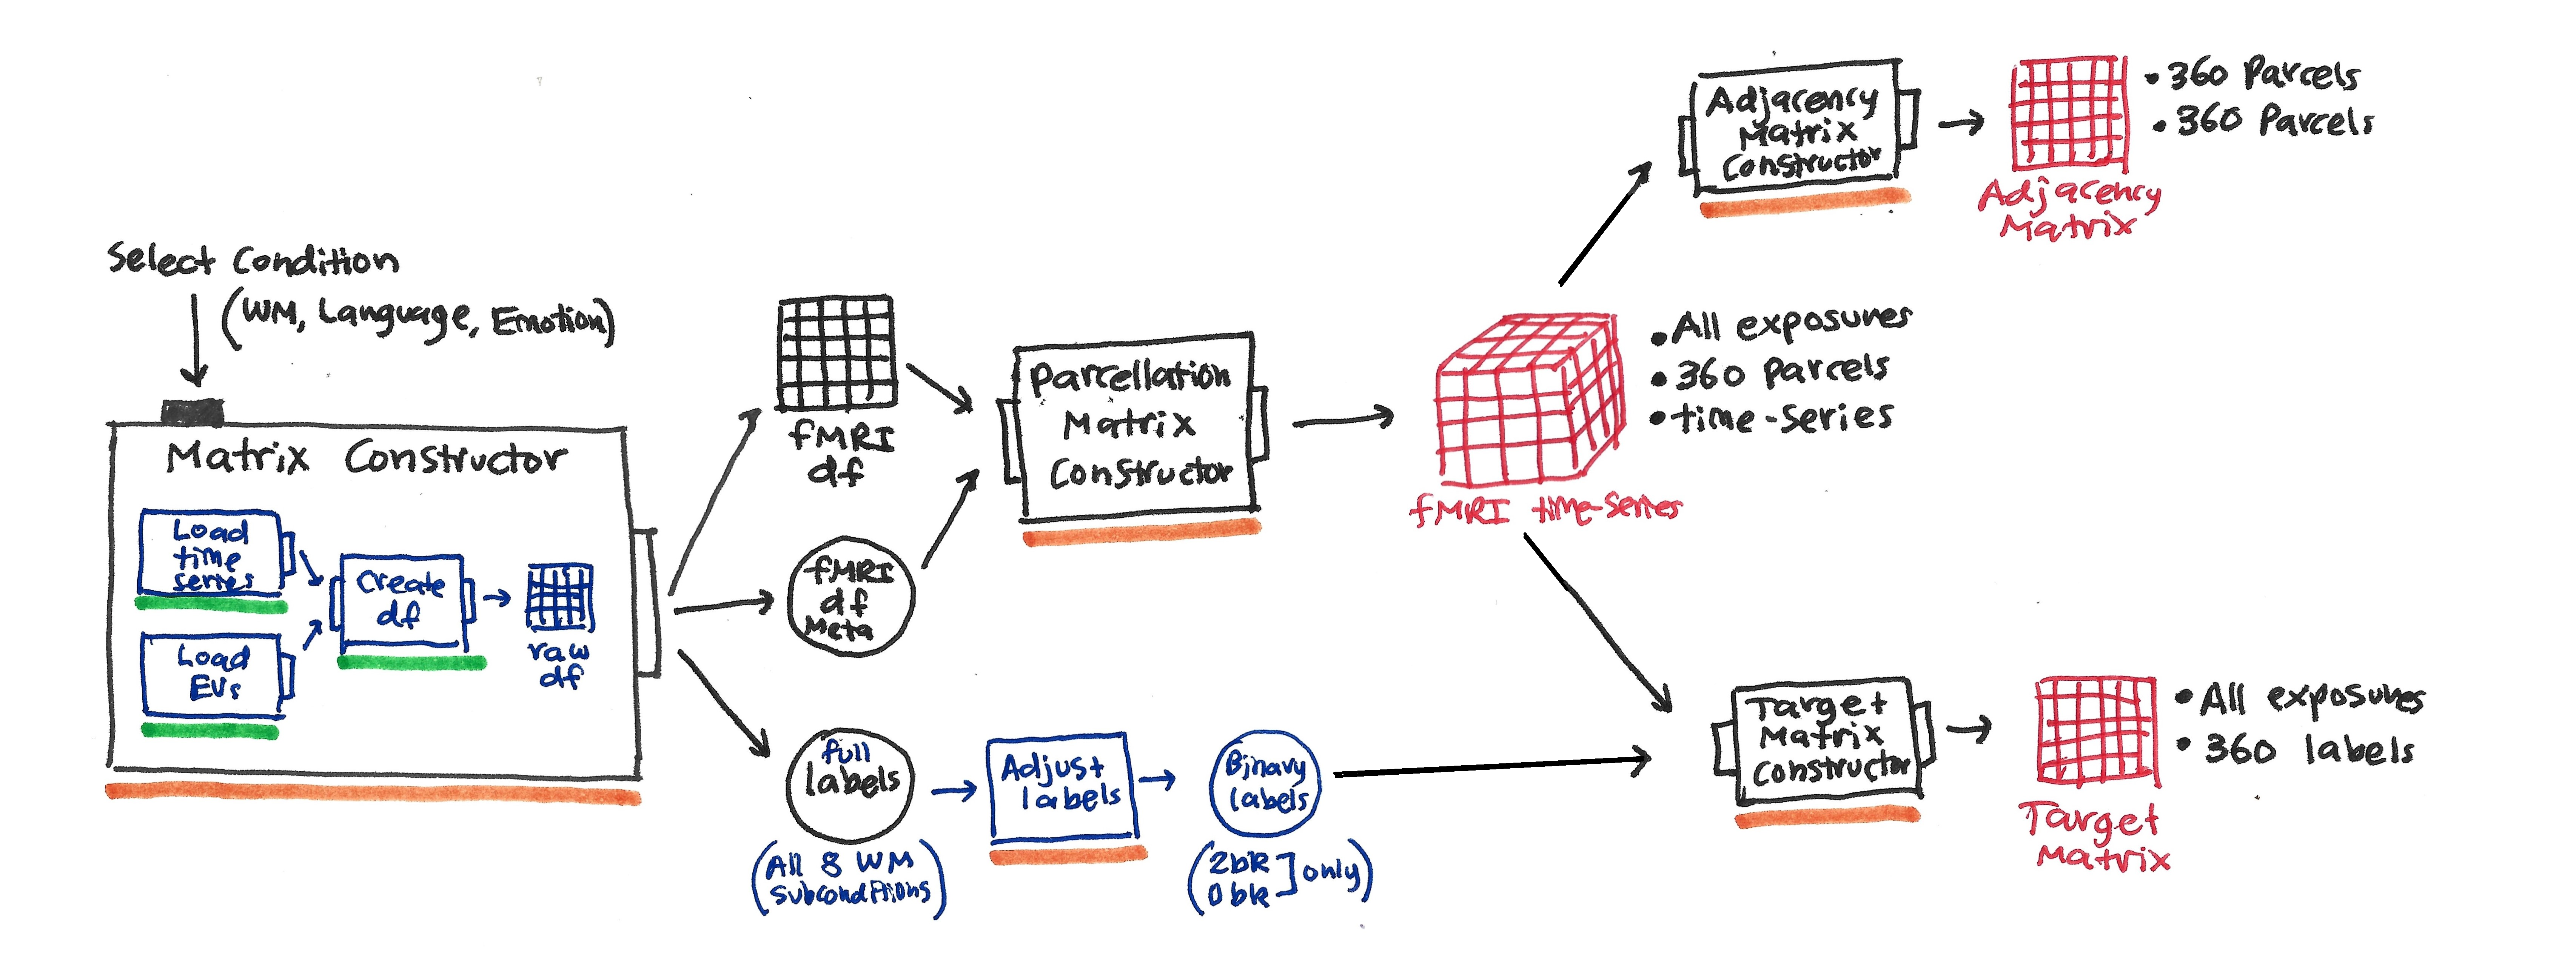
- **The Matrix construction** function utilises the prior helper functions to create a raw matrix representing the fMRI data, along with a subcondition label array. The Parcellation Matrix constructor in turn re-orients this data into a 3D matrix with the correct dimensions for the model. This is done for the WM task, but also for the emotion and language conditions.
- **The adjacency matrix** constructor takes the processed fMRI time series, averages the time steps out and uses covariannce to construct a connectome representation, with sparsity to remove weaker connections. This is later passed to the GNN input stream. This process is done for the WM condition along with the language and emotion conditons.
- **The Target matrix** constructor takes the label data and processes it into a matrix where each column presents a binarized activation for each parcel with respect to 2-back task exposures. This is used to create the label columns utilised by the model, with masking to remove columns that aren't selected as outputs. This matrix has a high degree of sparsity, so using two many at once tends to degrade the models performance. This is only used for the WM data, not the other conditions.

In [21]:
BASE_TEMP_DIR = "./WMAD_processing_temp_files"

if not os.path.exists(BASE_TEMP_DIR):
    os.makedirs(BASE_TEMP_DIR)
    print(f"Created temporary directory: {BASE_TEMP_DIR}")

#### Run pipeline for Working Memory

In [25]:
WM_SUBJECT_TEMP_DIR = os.path.join(BASE_TEMP_DIR, "WM_subject_data")

WM_FMRI_WM_PATH     = os.path.join(WM_SUBJECT_TEMP_DIR, "wm_fmri_wm.npy")
WM_METADATA_WM_PATH = os.path.join(WM_SUBJECT_TEMP_DIR, "wm_metadata_wm.pkl")

WM_COMBINED_FMRI_PATH       = os.path.join(BASE_TEMP_DIR, "wm_combined_all_fmri_data.npy")
WM_COMBINED_LABELS_PATH     = os.path.join(BASE_TEMP_DIR, "wm_combined_all_labels.npy")
WM_COMBINED_DATAFRAMES_PATH = os.path.join(BASE_TEMP_DIR, "wm_combined_all_dataframes.pkl")

In [23]:
# 1. Process and Save Subject Data Iteratively (WM)
WM_SUBJECT_DATA_PATHS = matrix_setup_all_subjects_iterative_save("WM", SubjectIDs, output_dir = WM_SUBJECT_TEMP_DIR)


✅ Finished processing and saving all subjects. Individual subject data saved to: ./WMAD_processing_temp_files/WM_subject_data


In [ ]:
# 2. Load and Combine Subject Data (WM)
all_fmri_data_wm, all_labels_wm, all_dataframes_wm = load_and_combine_subject_data(WM_SUBJECT_DATA_PATHS)

# Save the combined data to disk
if all_fmri_data_wm is not None:
    print("\nSaving combined WM data...")
    np.save(WM_COMBINED_FMRI_PATH, all_fmri_data_wm)
    np.save(WM_COMBINED_LABELS_PATH, all_labels_wm)
    with open(WM_COMBINED_DATAFRAMES_PATH, "wb") as f:
        pickle.dump(all_dataframes_wm, f)
    print(f"Combined WM data saved to: {BASE_TEMP_DIR}")

    # Release the memory
    del all_fmri_data_wm
    del all_labels_wm
    del all_dataframes_wm
    print("Combined WM data variables deleted from memory.")

    # 3. Adjust Labels (WM)
    # Load labels back from disk
    all_labels_wm = np.load(WM_COMBINED_LABELS_PATH)
    binary_labels_wm = adjust_wm_labels(all_labels_wm)

    # 4. Construct and Save/Load Parcellation Matrix (WM)
    # Load combined fMRI data and dataframes if not already in memory
    if not 'fmri_wm' in locals() and os.path.exists(WM_COMBINED_FMRI_PATH) and os.path.exists(WM_COMBINED_DATAFRAMES_PATH):
        print("\nLoading combined WM fMRI data and dataframes for parcellation...")
        all_fmri_data_wm = np.load(WM_COMBINED_FMRI_PATH)
        with open(WM_COMBINED_DATAFRAMES_PATH, "rb") as f:
            all_dataframes_wm = pickle.load(f)

        if not os.path.exists(WM_FMRI_WM_PATH) or not os.path.exists(WM_METADATA_WM_PATH):
            print("\n\nConstructing parcellation matrix for WM...")
            fmri_wm, metadata_WM = construct_parcellation_matrix(all_fmri_data_wm, all_dataframes_wm, Standardize=True)
            np.save(WM_FMRI_WM_PATH, fmri_wm)
            with open(WM_METADATA_WM_PATH, "wb") as f:
                pickle.dump(metadata_WM, f)
            print(f"Parcellation matrix and metadata for WM saved to: {WM_SUBJECT_TEMP_DIR}")
        else:
            print(f"Loading parcellation matrix and metadata for WM from: {WM_SUBJECT_TEMP_DIR}")
            fmri_wm = np.load(WM_FMRI_WM_PATH)
            with open(WM_METADATA_WM_PATH, "rb") as f:
                metadata_WM = pickle.load(f)
            print(f"Parcellation matrix and metadata for WM loaded from: {WM_SUBJECT_TEMP_DIR}")

        # Release combined data memory after parcellation
        del all_fmri_data_wm
        del all_dataframes_wm
        print("Combined WM fMRI data and dataframes deleted from memory after parcellation.")

        # 5. Construct Target Matrix (WM)
        target_matrix_wm = construct_target_matrix(fmri_wm, binary_labels_wm, percentile_threshold=75)

        # 6. Construct Adjacency Matrix (WM)
        adj_matrix_wm, louvain_partition_wm = construct_adjacency_matrix(fmri_wm, threshold=0.3, binarize=True,
                                                                           region_labels=Glasser_parcels_labels)
    else:
        print("Error: Combined WM fMRI data or dataframes not available.")


Loading and combining subject data...
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/100307_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subject_data/100307_dataframe.pkl
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/100408_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subject_data/100408_dataframe.pkl
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/101915_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subject_data/101915_dataframe.pkl
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/102816_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subject_data/102816_dataframe.pkl
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/103414_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subject_data/103414_dataframe.pkl
Loaded data from: ./WMAD_processing_temp_files/WM_subject_data/103515_data.npz and DataFrame from: ./WMAD_processing_temp_files/WM_subje

#### Run pipeline for Emotion

In [ ]:
EMOTION_SUBJECT_TEMP_DIR      = os.path.join(BASE_TEMP_DIR, "EMOTION_subject_data")

EMOTION_FMRI_EMOTION_PATH     = os.path.join(EMOTION_SUBJECT_TEMP_DIR, "emotion_fmri_emotion.npy")
EMOTION_METADATA_EMOTION_PATH = os.path.join(EMOTION_SUBJECT_TEMP_DIR, "emotion_metadata_emotion.pkl")

# Process and Save Subject Data Iteratively (EMOTION)
EMOTION_SUBJECT_DATA_PATHS = matrix_setup_all_subjects_iterative_save("EMOTION", SubjectIDs, output_dir = EMOTION_SUBJECT_TEMP_DIR)

# Load and Combine Subject Data (EMOTION)
all_fmri_emotion, all_labels_emotion, all_dataframes_emotion = load_and_combine_subject_data(EMOTION_SUBJECT_DATA_PATHS)

# Construct and Save/Load Parcellation Matrix (EMOTION)
if all_fmri_emotion is not None:
    if not os.path.exists(EMOTION_FMRI_EMOTION_PATH) or not os.path.exists(EMOTION_METADATA_EMOTION_PATH):
        print("Constructing parcellation matrix for EMOTION...")
        fmri_emotion, metadata_emotion = construct_parcellation_matrix(all_fmri_emotion, all_dataframes_emotion, Standardize = True)
        np.save(EMOTION_FMRI_EMOTION_PATH, fmri_emotion)
        with open(EMOTION_METADATA_EMOTION_PATH, "wb") as f:
            pickle.dump(metadata_emotion, f)
        print(f"Parcellation matrix and metadata for EMOTION saved to: {EMOTION_SUBJECT_TEMP_DIR}")
    else:
        print(f"Loading parcellation matrix and metadata for EMOTION from: {EMOTION_SUBJECT_TEMP_DIR}")
        fmri_emotion = np.load(EMOTION_FMRI_EMOTION_PATH)
        with open(EMOTION_METADATA_EMOTION_PATH, "rb") as f:
            metadata_emotion = pickle.load(f)
        print(f"Parcellation matrix and metadata for EMOTION loaded from: {EMOTION_SUBJECT_TEMP_DIR}")

    # Construct Adjacency Matrix (EMOTION)
    adj_matrix_emotion = construct_adjacency_matrix(fmri_emotion, threshold = 0.3, binarize = True)

else:
    print("Error: Could not load EMOTION subject data. Pipeline halted for EMOTION.")

#### Run pipeline for Language

In [ ]:
LANGUAGE_SUBJECT_TEMP_DIR       = os.path.join(BASE_TEMP_DIR, "LANGUAGE_subject_data")

LANGUAGE_FMRI_LANGUAGE_PATH     = os.path.join(LANGUAGE_SUBJECT_TEMP_DIR, "language_fmri_language.npy")
LANGUAGE_METADATA_LANGUAGE_PATH = os.path.join(LANGUAGE_SUBJECT_TEMP_DIR, "language_metadata_language.pkl")

# Process and Save Subject Data Iteratively (LANGUAGE)
LANGUAGE_SUBJECT_DATA_PATHS = matrix_setup_all_subjects_iterative_save("LANGUAGE", SubjectIDs, output_dir = LANGUAGE_SUBJECT_TEMP_DIR)

# Load and Combine Subject Data (LANGUAGE)
all_fmri_language, all_labels_language, all_dataframes_language = load_and_combine_subject_data(LANGUAGE_SUBJECT_DATA_PATHS)

# Construct and Save/Load Parcellation Matrix (LANGUAGE)
if all_fmri_language is not None:
    if not os.path.exists(LANGUAGE_FMRI_LANGUAGE_PATH) or not os.path.exists(LANGUAGE_METADATA_LANGUAGE_PATH):
        print("Constructing parcellation matrix for LANGUAGE...")
        fmri_language, metadata_language = construct_parcellation_matrix(all_fmri_language, all_dataframes_language, Standardize = True)
        np.save(LANGUAGE_FMRI_LANGUAGE_PATH, fmri_language)
        with open(LANGUAGE_METADATA_LANGUAGE_PATH, "wb") as f:
            pickle.dump(metadata_language, f)
        print(f"Parcellation matrix and metadata for LANGUAGE saved to: {LANGUAGE_SUBJECT_TEMP_DIR}")
    else:
        print(f"Loading parcellation matrix and metadata for LANGUAGE from: {LANGUAGE_SUBJECT_TEMP_DIR}")
        fmri_language = np.load(LANGUAGE_FMRI_LANGUAGE_PATH)
        with open(LANGUAGE_METADATA_LANGUAGE_PATH, "rb") as f:
            metadata_language = pickle.load(f)
        print(f"Parcellation matrix and metadata for LANGUAGE loaded from: {LANGUAGE_SUBJECT_TEMP_DIR}")

    # Construct Adjacency Matrix (LANGUAGE)
    adj_matrix_language = construct_adjacency_matrix(fmri_language, threshold = 0.3, binarize = True)

else:
    print("Error: Could not load LANGUAGE subject data. Pipeline halted for LANGUAGE.")

## Model Training

### Model preprocessing and training helper functions

In [1]:
def validate_pipeline_output(fmri_wm, target_matrix_wm, adj_matrix):
    """Runs diagnostic checks on the pipeline outputs to ensure compatibility with the GNN-LSTM-MLP model.

    Arguments:
        fmri_wm          (np.ndarray): Parcellation matrix (n_exposures, 360, time_steps)
        target_matrix_wm (np.ndarray): Target matrix (n_exposures, 360)
        adj_matrix       (np.ndarray): Adjacency matrix (360, 360)
        
    Returns:
        bool: True if all checks pass, False otherwise.
    """
    print("\n===== Running Pipeline Diagnostics =====")

    # ✅ **Check Shapes**
    expected_fmri_shape   = (fmri_wm.shape[0], 360, fmri_wm.shape[2])  # Expecting (batch_size, 360, time_steps)
    expected_target_shape = (fmri_wm.shape[0], 360)                    # Expecting (batch_size, 360)
    expected_adj_shape    = (360, 360)                                 # Expecting (360, 360)

    print(f"🔹 fMRI Parcellation Matrix Shape: {fmri_wm.shape}, Expected: {expected_fmri_shape}")
    print(f"🔹 Target Matrix Shape: {target_matrix_wm.shape}, Expected: {expected_target_shape}")
    print(f"🔹 Adjacency Matrix Shape: {adj_matrix.shape}, Expected: {expected_adj_shape}")

    if fmri_wm.shape != expected_fmri_shape:
        print("❌ ERROR: Parcellation matrix shape mismatch!")
        return False
    if target_matrix_wm.shape != expected_target_shape:
        print("❌ ERROR: Target matrix shape mismatch!")
        return False
    if adj_matrix.shape != expected_adj_shape:
        print("❌ ERROR: Adjacency matrix shape mismatch!")
        return False

    # Convert to Torch Tensors
    fmri_wm          = torch.tensor(fmri_wm         , dtype = torch.float32)
    target_matrix_wm = torch.tensor(target_matrix_wm, dtype = torch.float32)

    # Convert adjacency matrix to PyTorch Geometric sparse format
    adj_matrix_tensor     = torch.tensor(adj_matrix, dtype = torch.float32)
    edge_index, edge_attr = dense_to_sparse(adj_matrix_tensor)  # Converts dense adj matrix to sparse format

    print(f"🔹 fMRI Data Type: {fmri_wm.dtype}, Expected: torch.float32")
    print(f"🔹 Target Matrix Data Type: {target_matrix_wm.dtype}, Expected: torch.float32")
    print(f"🔹 Adjacency Matrix Converted to Sparse Format (Edges: {edge_index.shape[1]})")

    # Check Normalization
    if not np.allclose(fmri_wm.mean().item(), 0, atol = 1e-1):
        print("⚠️ WARNING: fMRI data may not be properly Standardized (mean not ~0).")
    
    if not np.allclose(fmri_wm.std().item() , 1, atol = 1e-1):
        print("⚠️ WARNING: fMRI data may not be properly Standardized (std not ~1).")

    print("✅ All checks passed! Data is ready for the model.")
    return True

In [2]:
def create_graph_data(fmri_sample, edge_index):
    """Converts an fMRI sample and edge index into a PyTorch Geometric Data object.

    Arguments:
        fmri_sample   (np.ndarray): fMRI data sample which can be 1D (time_steps) or 2D (time_steps, num_features)
        edge_index  (torch.Tensor): Graph connectivity in COO format [2, num_edges]

    Returns:
        torch_geometric.data.Data: A Data object containing node features (x) and edge indices
    """
    if fmri_sample.ndim == 1:
        fmri_sample = fmri_sample.reshape(-1, 1)
    
    x = fmri_sample[:, -1].clone().detach().unsqueeze(-1).expand(-1, 64).float()
    
    edge_index = edge_index.clone()
    
    return Data(x=x, edge_index=edge_index)

In [3]:
def create_batched_graphs(fmri_batch, edge_index):
    """Creates a batched graph from a batch of fMRI samples and a single edge index.

    Arguments:
        fmri_batch   (np.ndarray): Batch of fMRI data samples (batch_size, time_steps, num_features)
        edge_index (torch.Tensor): Graph connectivity in COO format [2, num_edges] which is shared across the batch

    Returns:
        torch_geometric.data.Batch: A batched Data object suitable for graph neural network processing
    """
    data_list = [create_graph_data(fmri_batch[i], edge_index.clone()) for i in range(fmri_batch.shape[0])]
    
    return Batch.from_data_list(data_list)

### Model setup helper functions

In [4]:
class GNN_LSTM_Fusion(nn.Module):
    """A hybrid neural network model combining Graph Neural Networks (GNNs),
    Long Short-Term Memory (LSTM) networks, and Multi-Layer Perceptrons (MLPs)
    for processing graph-structured and sequential data.
    """
    def __init__(self, num_parcels =  360,
                 selected_parcels  = None,
                 num_lstm_layers   =    2,
                 lstm_hidden       =   64,
                 num_gat_layers    =    2,
                 gat_hidden        =   64,
                 fusion_hidden     =  128,
                 mlp_hidden_layers = [120, 240] ,
                 dropout_rates     = {"gat": 0.2, "lstm": 0.2, "mlp": 0.3}):
        """Initializes the GNN_LSTM_Fusion model.

        Args:
        num_parcels               (int, optional): The total number of brain regions (nodes). Defaults to 360.
        selected_parcels         (list, optional): Indices of the brain regions to be used for the final output.
                                                   If None, all `num_parcels` are used. Defaults to None.
        num_lstm_layers           (int, optional): Number of LSTM layers. Defaults to 2.
        lstm_hidden               (int, optional): Hidden size of the LSTM layers. Defaults to 64.
        num_gat_layers            (int, optional): Number of Graph Attention Network (GAT) layers. Defaults to 2.
        gat_hidden                (int, optional): Hidden size of the GAT layers. Defaults to 64.
        fusion_hidden             (int, optional): Hidden size after the GAT layers, before fusion with LSTM output. Defaults to 128.
        mlp_hidden_layers (list of int, optional): A list defining the sizes of the hidden layers in the MLP.
                                                   Defaults to [120, 240].
        dropout_rates            (dict, optional): A dictionary specifying dropout rates for different components ("gat", "lstm", "mlp").
                                                   Defaults to {"gat": 0.2, "lstm": 0.2, "mlp": 0.3}.
        """
        super(GNN_LSTM_Fusion, self).__init__()

        self.selected_parcels = selected_parcels if selected_parcels else list(range(num_parcels))

        # GAT Layers
        self.gat_layers = nn.ModuleList()
        in_channels = 64
        for i in range(num_gat_layers):
            out_channels = gat_hidden if i < num_gat_layers - 1 else fusion_hidden
            self.gat_layers.append(GATConv(in_channels, out_channels, heads = 4, concat = False, dropout = dropout_rates["gat"]))
            in_channels = out_channels

        # LSTM Component
        self.lstm = nn.LSTM(input_size  = num_parcels, hidden_size = lstm_hidden, num_layers = num_lstm_layers,
                            batch_first = True       , dropout     = dropout_rates["lstm"])

        # MLP Layers
        mlp_layers = []
        mlp_input_size = fusion_hidden + lstm_hidden
        for mlp_size in mlp_hidden_layers:
            mlp_layers.append(nn.Linear(mlp_input_size, mlp_size))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(dropout_rates["mlp"]))
            mlp_input_size = mlp_size

        self.mlp    = nn.Sequential(*mlp_layers)
        self.fc_out = nn.Linear(mlp_hidden_layers[-1], len(self.selected_parcels))

    def forward(self, fmri_sequence, batch_graph):
        """Forward pass of the GNN-LSTM-Fusion model.

        Args:
            fmri_sequence             (torch.Tensor): Batch of fMRI time series data of shape (batch_size, num_parcels, time_steps).
            batch_graph (torch_geometric.data.Batch): A batched graph data object containing node features and edge indices for the batch.

        Returns:
            torch.Tensor: The model output, typically a probability distribution over the
                          "selected_parcels", with shape (batch_size, len(self.selected_parcels)).
        """
        batch_size, num_parcels, time_steps = fmri_sequence.shape

        # GAT Processing
        x_gat      = batch_graph.x
        edge_index = batch_graph.edge_index
        
        for gat_layer in self.gat_layers:
            x_gat = F.relu(gat_layer(x_gat, edge_index))
        
        x_gat = global_mean_pool(x_gat, batch_graph.batch)

        # LSTM Processing
        fmri_sequence = fmri_sequence.permute(0, 2, 1)
        lstm_out, _   = self.lstm(fmri_sequence)
        
        x_lstm = lstm_out[:, -1, :]

        # Fusion + MLP Processing
        fused  = torch.cat((x_gat, x_lstm), dim = -1)
        fused  = self.mlp(fused)
        output = torch.sigmoid(self.fc_out(fused))

        return output

NameError: name 'nn' is not defined

In [ ]:
def evaluate_model(model, data_loader, criterion, edge_index, device = "cpu"):
    """Evaluates the given neural network model on the provided data loader.

    Args:
        model                   (torch.nn.Module): The neural network model to evaluate.
        data_loader (torch.utils.data.DataLoader): DataLoader for the evaluation dataset.
        criterion               (torch.nn.Module): The loss function.
        edge_index                 (torch.Tensor): The adjacency information for the graph.
        device                    (str, optional): The device to evaluate on ('cpu' or 'cuda'). Defaults to 'cpu'.

    Returns:
        tuple: A tuple containing the average loss, accuracy, precision, recall, and F1 score
               on the evaluation dataset.
    """
    model.eval()
    total_loss, all_preds, all_targets = 0, [], []
    
    with torch.no_grad():
        for fmri_batch, target_batch in data_loader:
            batch_graph = create_batched_graphs(fmri_batch, edge_index)
            output      = model(fmri_batch.to(device), batch_graph.to(device))
            loss        = criterion(output, target_batch[:, model.selected_parcels].to(device))
            total_loss  = total_loss + loss.item()

            preds   = (output > 0.5).cpu().numpy()
            targets = target_batch[:, model.selected_parcels].cpu().numpy()
            all_preds.append(preds)
            all_targets.append(targets)

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    accuracy    = accuracy_score(  all_targets.flatten(), all_preds.flatten())
    precision   = precision_score( all_targets.flatten(), all_preds.flatten(), average = "macro", zero_division = 0)
    recall      = recall_score(    all_targets.flatten(), all_preds.flatten(), average = "macro", zero_division = 0)
    f1          = f1_score(        all_targets.flatten(), all_preds.flatten(), average = "macro", zero_division = 0)
    avg_loss    = total_loss / len(data_loader)

    return avg_loss, accuracy, precision, recall, f1

In [ ]:
def train_model(model    , train_loader, val_loader     ,
                optimizer, criterion   , edge_index     ,
                num_epochs = 10        , device = "cpu"):
    """Trains the given neural network model. Works with the evaluate_model() function.

    Args:
        model                    (torch.nn.Module): The neural network model to train.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        val_loader   (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        optimizer          (torch.optim.Optimizer): The optimizer used for training.
        criterion                (torch.nn.Module): The loss function.
        edge_index                  (torch.Tensor): The adjacency information for the graph.
        num_epochs                 (int, optional): The number of training epochs. Defaults to 10.
        device                     (str, optional): The device to train on ('cpu' or 'cuda'). Defaults to "cpu".

    Returns:
        dict: A dictionary containing the training and validation history for loss, accuracy,
              precision, recall, and F1 score for each epoch.
    """
    history = {
        "train_loss"  : [], "val_loss"  : [],
        "train_acc"   : [], "val_acc"   : [],
        "train_f1"    : [], "val_f1"    : [],
        "train_prec"  : [], "val_prec"  : [],
        "train_recall": [], "val_recall": []
    }

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        y_true_train, y_pred_train = [], []

        for fmri_batch, target_batch in train_loader:
            optimizer.zero_grad()
            batch_graph = create_batched_graphs(fmri_batch, edge_index)
            outputs     = model(fmri_batch.to(device), batch_graph.to(device))

            labels = target_batch[:, model.selected_parcels].to(device)
            loss   = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss = total_loss + loss.item()

            preds = (outputs > 0.5).float()
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        # Train Metrics
        train_loss   = total_loss / len(train_loader)
        train_acc    = accuracy_score(  y_true_train, y_pred_train)
        train_prec   = precision_score( y_true_train, y_pred_train, average = "macro", zero_division = 0)
        train_recall = recall_score(    y_true_train, y_pred_train, average = "macro", zero_division = 0)
        train_f1     = f1_score(        y_true_train, y_pred_train, average = "macro", zero_division = 0)

        # Validation Metrics
        val_loss, val_acc, val_prec, val_recall, val_f1 = evaluate_model(model, val_loader, criterion, edge_index, device = device)

        # Log
        history["train_loss"  ].append(train_loss)
        history["val_loss"    ].append(val_loss)
        history["train_acc"   ].append(train_acc)
        history["val_acc"     ].append(val_acc)
        history["train_f1"    ].append(train_f1)
        history["val_f1"      ].append(val_f1)
        history["train_prec"  ].append(train_prec)
        history["train_recall"].append(train_recall)
        history["val_prec"    ].append(val_prec)
        history["val_recall"  ].append(val_recall)

        # Print Status
        print(f"Epoch {epoch + 1}:")
        print(f"======== Train: Loss {train_loss:.4f}, Acc {train_acc:.4f}, Prec {train_prec:.4f}, Recall {train_recall:.4f}, F1 {train_f1:.4f}")
        print(f"======== Valid: Loss {val_loss  :.4f}, Acc {val_acc  :.4f}, Prec {val_prec  :.4f}, Recall {val_recall  :.4f}, F1 {val_f1  :.4f}")

    return history

In [ ]:
def freeze_layers(model,
                  freeze_gat  = False,
                  freeze_lstm = False,
                  freeze_mlp  = False):
    """Freezes the parameters of specified layers within the model.

    Args:
        model      (torch.nn.Module): The neural network model.
        freeze_gat  (bool, optional): If True, freezes the parameters of the GAT layers. Defaults to False.
        freeze_lstm (bool, optional): If True, freezes the parameters of the LSTM layers. Defaults to False.
        freeze_mlp  (bool, optional): If True, freezes the parameters of the MLP layers. Defaults to False.
    """
    for param in model.gat_layers.parameters():
        param.requires_grad = not freeze_gat
    for param in model.lstm.parameters():
        param.requires_grad = not freeze_lstm
    for param in model.mlp.parameters():
        param.requires_grad = not freeze_mlp
    for param in model.fc_out.parameters():
        param.requires_grad = True

In [ ]:
def plot_training_metrics(history, title_prefix=""):
    """Plots training and validation metrics from the training history.

    Supports plotting of: train_loss, val_loss, train_acc, val_acc, train_f1, val_f1, val_prec, val_recall.

    Args:
        history (dict): A dictionary containing the training and validation metrics for each epoch.
                        Expected keys include: "train_loss", "val_loss", and optionally
                        "train_acc", "val_acc", "train_f1", "val_f1", "val_prec", "val_recall".
        title_prefix (str, optional): A string to prepend to the titles of the plots. Defaults to "".
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize = (12, 10))

    # Loss Plot
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["train_loss"], label = "Train Loss")
    plt.plot(epochs, history["val_loss"  ], label = "Val Loss"  )
    plt.title(f"{title_prefix} Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.ylim(0, 1)
    plt.legend()

    # Accuracy Plot
    plt.subplot(2, 2, 2)
    if "train_acc" in history:
        plt.plot(epochs, history["train_acc"], label = "Train Accuracy")
    if "val_acc" in history:
        plt.plot(epochs, history["val_acc"], label = "Val Accuracy")
    plt.title(f"{title_prefix} Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()

    # Precision and Recall (Validation Only)
    plt.subplot(2, 2, 3)
    if "val_prec" in history:
        plt.plot(epochs, history["val_prec"], label = "Val Precision")
    if "val_recall" in history:
        plt.plot(epochs, history["val_recall"], label = "Val Recall")
    plt.title(f"{title_prefix} Validation Precision and Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()

    # F1 Score Plot
    plt.subplot(2, 2, 4)
    if "train_f1" in history:
        plt.plot(epochs, history["train_f1"], label = "Train F1")
    if "val_f1" in history:
        plt.plot(epochs, history["val_f1"], label = "Val F1")
    plt.title(f"{title_prefix} F1 Score Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1)
    plt.legend()

    plt.tight_layout()
    plt.show()

### Run data check

In [ ]:
validate_pipeline_output(fmri_wm, target_matrix_wm, adj_matrix)

### Split WM data into train and test sets
Here, we split indices (subject-wise split is preferred but not available, so we use exposure-wise).

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(np.arange(fmri_wm.shape[0]),
                                      test_size = 0.2, random_state = 42)

train_parcel = fmri_wm[train_idx]  # Shape: (train_exposures, 360, time_steps)
val_parcel   = fmri_wm[val_idx]    # Shape: (val_exposures  , 360, time_steps)

train_target = target_matrix_wm[train_idx]  # Shape: (train_exposures, 360)
val_target   = target_matrix_wm[val_idx]    # Shape: (val_exposures  , 360)

### Standardize split data

In [ ]:
from sklearn.preprocessing import StandardScaler

scalers = [StandardScaler() for _ in range(360)]

# Apply standardization (per parcel, across time)
for i in range(360):
    train_parcel[:, i, :] = scalers[i].fit_transform(train_parcel[:, i, :])
    val_parcel[:, i, :]   = scalers[i].transform(val_parcel[:, i, :])


### Final preparations and format conversions for training

In [ ]:
import torch
import torch_geometric.utils as pyg_utils

from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# Set device (Use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move fMRI data to GPU (if available) and convert to tensors
train_parcel_tensor = torch.from_numpy(train_parcel).float().to(device)
val_parcel_tensor   = torch.from_numpy(val_parcel).float().to(device)
train_target_tensor = torch.from_numpy(train_target).float().to(device)
val_target_tensor   = torch.from_numpy(val_target).float().to(device)

# Convert adjacency matrix once and move to device
adj_matrix_tensor     = torch.from_numpy(adj_matrix).float().to(device)
edge_index, edge_attr = pyg_utils.dense_to_sparse(adj_matrix_tensor)

In [ ]:
batch_size = 32

# Create PyTorch datasets
train_dataset = TensorDataset(train_parcel_tensor, train_target_tensor)
val_dataset   = TensorDataset(val_parcel_tensor  , val_target_tensor  )

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle =  True, num_workers = 0, pin_memory = False)
val_loader   = DataLoader(val_dataset  , batch_size = batch_size, shuffle = False, num_workers = 0, pin_memory = False)

# Prepare additional datasets (Emotion, Language, and WM tasks)
emotion_parcel_tensor  = torch.from_numpy(fmri_emotion).float().to(device)
language_parcel_tensor = torch.from_numpy(fmri_language).float().to(device)
wm_parcel_tensor       = torch.from_numpy(fmri_wm).float().to(device)

test_dataset_emotion  = TensorDataset(emotion_parcel_tensor)
test_dataset_language = TensorDataset(language_parcel_tensor)
test_dataset_wm       = TensorDataset(wm_parcel_tensor)

test_loader_emotion  = DataLoader(test_dataset_emotion , batch_size = batch_size, shuffle = False)
test_loader_language = DataLoader(test_dataset_language, batch_size = batch_size, shuffle = False)
test_loader_wm       = DataLoader(test_dataset_wm      , batch_size = batch_size, shuffle = False)

# Print confirmation of shapes
print(f"✅ Data successfully loaded to {device}:")
print(f"==== train_parcel_tensor: {train_parcel_tensor.shape}")
print(f"==== val_parcel_tensor: {val_parcel_tensor.shape}")
print(f"==== train_target_tensor: {train_target_tensor.shape}")
print(f"==== val_target_tensor: {val_target_tensor.shape}")
print(f"==== adj_matrix_tensor (sparse): {edge_index.shape}")

### Hyperparameter search

#### Helper function for hyperparameter search

In [ ]:
def random_hyperparameter_search(model_class, train_loader, val_loader, edge_index, base_num_parcels,
                                 parcel_pool    ,          # List of available parcel indices
                                 mlp_options    ,          # List of MLP architectures
                                 lstm_configs   ,          # List of (layers, hidden_size) tuples
                                 gat_configs    ,          # List of (layers, hidden_size) tuples
                                 dropout_options,          # List of dropout dicts
                                 epoch_ranges   ,          # Dict with keys 'gat', 'lstm', 'full'
                                 num_trials = 30, accuracy_threshold = 0.85, f1_threshold = 0.60, max_epochs = 50,
                                 device="cuda" if torch.cuda.is_available() else "cpu"):
    """Performs a random search over a defined hyperparameter space to find the best model configuration.

    Args:
        model_class              (torch.nn.Module): The class of the neural network model to be instantiated.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        val_loader   (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        edge_index                  (torch.Tensor): The adjacency information for the graph.
        base_num_parcels                     (int): The total number of brain regions (nodes).
        parcel_pool                         (list): A list of integer indices representing the available brain regions to select from.
        mlp_options          (list of list of int): A list where each inner list defines a possible MLP architecture
                                                    (e.g., [120, 240] for two hidden layers of size 120 and 240).
        lstm_configs        (list of tuple of int): A list of tuples, where each tuple contains (num_lstm_layers, lstm_hidden_size).
        gat_configs         (list of tuple of int): A list of tuples, where each tuple contains (num_gat_layers, gat_hidden_size).
        dropout_options             (list of dict): A list of dictionaries, where each dictionary specifies dropout rates
                                                    for 'gat', 'lstm', and 'mlp' (e.g., {'gat': 0.2, 'lstm': 0.2, 'mlp': 0.3}).
        epoch_ranges                        (dict): A dictionary with keys 'gat', 'lstm', and 'full', where each key maps to a list
                                                    of possible number of training epochs for the respective training phases.
        num_trials                 (int, optional): The number of random hyperparameter configurations to evaluate. Defaults to 30.
        accuracy_threshold       (float, optional): The target accuracy to reach for early stopping of the search. Defaults to 0.85.
        f1_threshold             (float, optional): The target F1 score to reach for early stopping of the search. Defaults to 0.60.
        max_epochs                 (int, optional): The maximum number of epochs to train for in any phase. Defaults to 50.
        device                     (str, optional): The device to train and evaluate on ("cuda" or "cpu").
                                                    Defaults to "cuda" if available, otherwise "cpu".

    Returns:
        list of dict: A list of dictionaries, where each dictionary contains the hyperparameters and
                      evaluation metrics (accuracy, F1 score) for a trial. The list is sorted by F1 score
                      (descending) and then by accuracy (descending).
    """
    def validate_model(model):
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch     = X_batch.to(device)
                y_batch     = y_batch[:, model.selected_parcels].to(device)
                graph_batch = create_batched_graphs(X_batch, edge_index).to(device)
                outputs     = model(X_batch, graph_batch)
                preds       = (outputs > 0.5).float()
                y_true.extend(y_batch.cpu().numpy())
                y_pred.extend(preds.cpu().numpy())
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average = "macro", zero_division = 0)
        return acc, f1

    def should_early_stop(metrics):
        if len(metrics) < 4:
            return False
        accs = [m[0] for m in metrics[-3:]]
        f1s  = [m[1] for m in metrics[-3:]]
        return all(x == accs[0] for x in accs) and any(all(x == f1s[0] for x in f1s),)

    results = []

    for trial in range(num_trials):
        # Sample hyperparameters
        selected_parcels  = sorted(parcel_pool)
        mlp_hidden_layers = random.choice(mlp_options)
        lstm_layers, lstm_hidden = random.choice(lstm_configs)
        gat_layers , gat_hidden  = random.choice(gat_configs)
        dropout_rates = random.choice(dropout_options)

        gat_ep  = random.choice(epoch_ranges["gat"])
        lstm_ep = random.choice(epoch_ranges["lstm"])
        full_ep = random.choice(epoch_ranges["full"])

        model_kwargs = {
            "num_parcels"       : base_num_parcels ,
            "selected_parcels"  : selected_parcels ,
            "num_lstm_layers"   : lstm_layers      ,
            "lstm_hidden"       : lstm_hidden      ,
            "num_gat_layers"    : gat_layers       ,
            "gat_hidden"        : gat_hidden       ,
            "fusion_hidden"     : 128              ,
            "mlp_hidden_layers" : mlp_hidden_layers,
            "dropout_rates"     : dropout_rates
        }

        print(f"\n🎲 Trial {trial+1}/{num_trials}")
        print(f"• Parcels: {selected_parcels}")
        print(f"• MLP: {mlp_hidden_layers}")
        print(f"• LSTM: {lstm_layers}x{lstm_hidden} | GAT: {gat_layers}x{gat_hidden}")
        print(f"• Dropout: {dropout_rates}")
        print(f"• Epochs: GAT = {gat_ep}, LSTM = {lstm_ep}, FULL = {full_ep}")

        try:
            model     = model_class(**model_kwargs).to(device)
            criterion = torch.nn.BCELoss()

            # GAT Training
            print("🔧 GAT Training")
            freeze_layers(model, freeze_gat = False, freeze_lstm =  True, freeze_mlp =  True)
            opt_gat = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.001)
            train_model(model, train_loader, val_loader, opt_gat, criterion, edge_index, num_epochs = min(gat_ep, max_epochs), device = device)

            # LSTM Training
            print("🔧 LSTM Training")
            freeze_layers(model, freeze_gat =  True, freeze_lstm = False, freeze_mlp =  True)
            opt_lstm = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
            train_model(model, train_loader, val_loader, opt_lstm, criterion, edge_index, num_epochs = min(lstm_ep, max_epochs), device = device)

            # FULL Training with freeze-detection
            print("🔧 FULL Training")
            freeze_layers(model, freeze_gat = False, freeze_lstm = False, freeze_mlp = False)
            opt_full = torch.optim.Adam(model.parameters(), lr = 0.001)

            freeze_check = []
            for epoch in range(min(full_ep, max_epochs)):
                print(f"🌐 FULL Epoch {epoch+1}")
                train_model(model, train_loader, val_loader, opt_full, criterion, edge_index, num_epochs = 1, device = device)
                acc, f1 = validate_model(model)
                print(f"🔍 Validation: Acc={acc:.3f}, F1={f1:.3f}")
                freeze_check.append((acc, f1))
                if should_early_stop(freeze_check):
                    print(f"❄️ Training frozen at epoch {epoch+1} → Acc={acc:.3f}, F1={f1:.3f}")
                    break

            final_acc, final_f1 = validate_model(model)

            results.append({
                "trial"    : trial + 1                 ,
                "parcels"  : selected_parcels          ,
                "mlp"      : mlp_hidden_layers         ,
                "lstm"     : (lstm_layers, lstm_hidden),
                "gat"      : (gat_layers , gat_hidden) ,
                "dropout"  : dropout_rates             ,
                "epochs"   : {"gat": gat_ep, "lstm": lstm_ep, "full": full_ep},
                "accuracy" : final_acc                 ,
                "f1"       : final_f1
            })

            if final_acc >= accuracy_threshold and final_f1 >= f1_threshold:
                print(f"🎯 Early stop: Performance threshold of acc = {accuracy_threshold} and f1 = {f1_threshold} met.")
                break

        except Exception as e:
            print(f"❌ Trial {trial+1} failed: {e}")
            continue

    # Summary
    sorted_results = sorted(results, key = lambda r: (r["f1"], r["accuracy"]), reverse = True)

    # Save the results
    os.makedirs("../models", exist_ok = True)
    filepath = os.path.join("../models", "hyperparameter_search_results.pkl")
    with open(filepath, "wb") as f:
        pickle.dump(sorted_results, f)
    print(f"\n💾 Hyperparameter search results saved to: {filepath}")

    print("\n🏁 Best Results:")
    for r in sorted_results[:5]:
        print(f"• Trial {r["trial"]} | Acc: {r["accuracy"]:.3f}, F1: {r["f1"]:.3f} | Epochs: {r["epochs"]}")
        print(f"  Parcels: {r["parcels"]} | MLP: {r["mlp"]} | LSTM: {r["lstm"]} | GAT: {r["gat"]} | Dropout: {r["dropout"]}")

    return sorted_results

#### Parameter selection

In [ ]:
torch.autograd.set_detect_anomaly(True)

parcel_pool = list(range(360))

mlp_options = [[130, 66, 30, 15] ,
               [100, 50, 25]     ,
               [128, 64]         ,
               [256, 128, 64, 32]]


lstm_configs = [(1,  64),
                (2,  64),
                (2, 128)]


gat_configs = [(1,  64),
               (2,  64),
               (2, 128)]


dropout_options = [{"gat": 0.1, "lstm": 0.1, "mlp": 0.2},
                   {"gat": 0.2, "lstm": 0.2, "mlp": 0.3}]


epoch_ranges = {"gat" : [ 5, 10, 15, 20]    ,
                "lstm": [ 5, 10, 15, 20]    ,
                "full": [10, 20, 30, 40, 50]}

In [ ]:
best_configs = random_hyperparameter_search(model_class        = GNN_LSTM_Fusion,
                                            train_loader       = train_loader   ,
                                            val_loader         = val_loader     ,
                                            edge_index         = edge_index     ,
                                            base_num_parcels   = 360            ,
                                            parcel_pool        = parcel_pool    ,
                                            mlp_options        = mlp_options    ,
                                            lstm_configs       = lstm_configs   ,
                                            gat_configs        = gat_configs    ,
                                            dropout_options    = dropout_options,
                                            epoch_ranges       = epoch_ranges   ,
                                            num_trials         = 100            ,  # ← Set your max sample count here
                                            accuracy_threshold = 0.85           ,
                                            f1_threshold       = 0.60           ,
                                            max_epochs         = 50             ,
                                            device             = device)           # You can hardcode the device if preferred

#### Defining parameters for training based on `best_configs`

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
edge_index = edge_index.to(device)

selected_parcels = list(range(360))

model = GNN_LSTM_Fusion(num_parcels       =  360,
                        selected_parcels  = selected_parcels,
                        num_lstm_layers   =    2,
                        lstm_hidden       =  128,
                        num_gat_layers    =    2,
                        gat_hidden        =   64,
                        fusion_hidden     =  128,
                        mlp_hidden_layers = [128, 64],  # Define MLP layers dynamically [130, 66, 30, 15]
                        
                        dropout_rates={"gat" : 0.2,     # Dropout for GAT layers
                                       "lstm": 0.2,     # Dropout for LSTM layers
                                       "mlp" : 0.3      # Dropout for MLP layers}
                        ).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-5)

criterion = nn.BCELoss()

In [ ]:
if best_configs:
    top_config = best_configs[0]
    model = GNN_LSTM_Fusion(
        num_parcels=360,
        selected_parcels=top_config['parcels'],
        num_lstm_layers=top_config['lstm'][0],
        lstm_hidden=top_config['lstm'][1],
        num_gat_layers=top_config['gat'][0],
        gat_hidden=top_config['gat'][1],
        fusion_hidden=128,
        mlp_hidden_layers=top_config['mlp'],
        dropout_rates=top_config['dropout']
    ).to(device)
else:
    # Fallback to a default configuration if best_configs is empty
    model = GNN_LSTM_Fusion(
        num_parcels=360,
        selected_parcels=list(range(360)),  # Use all parcels by default
        num_lstm_layers=2,
        lstm_hidden=128,
        num_gat_layers=2,
        gat_hidden=64,
        fusion_hidden=128,
        mlp_hidden_layers=[128, 64],
        dropout_rates={"gat": 0.2, "lstm": 0.2, "mlp": 0.3}
    ).to(device)

### Train and save models

**The Model is trained in 3 steps**
- The GNN component (GAT) is trained, saved, and the rest of the network is frozen
- Then LSTM trains while GAT and MLP are frozen
- Then the full model, including the MLP, component is trained

In [ ]:
models_temp_directory = "./models"
models_perm_directory = "../models"
os.makedirs(models_directory, exist_ok = True)

# Paths for saving non-final models:
gat_save_path  = os.path.join(models_temp_directory, "gat_pretrained_NotFinal.pth")
lstm_save_path = os.path.join(models_temp_directory, "lstm_pretrained_NotFinal.pth")
mlp_save_path  = os.path.join(models_temp_directory, "mlp_pretrained_NotFinal.pth")
WMAD_save_path = os.path.join(models_temp_directory, "full_model_state_dict_NotFinal.pth")

# Paths for final model save:
final_gat_path  = os.path.join(models_perm_directory, "WMAD_gat_pretrained.pth")
final_lstm_path = os.path.join(models_perm_directory, "WMAD_lstm_pretrained.pth")
final_mlp_path  = os.path.join(models_perm_directory, "WMAD_mlp_pretrained.pth")
final_WMAD_path = os.path.join(models_perm_directory, "WMAD_full_model_state_dict.pth")

In [ ]:
torch.cuda.empty_cache() 

In [ ]:
print("TRAINING GAT:")

freeze_layers(model, freeze_gat = False, freeze_lstm = True, freeze_mlp = True)
optimizer_gat = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.001)
model.to(device)

edge_index  = edge_index.to(device)
num_gat_epochs = top_config["epochs"]["gat"] if best_configs and "epochs" in best_configs[0] and "gat" in best_configs[0]["epochs"] else 5
gat_history = train_model(model, train_loader, val_loader, optimizer_gat, criterion, edge_index, num_epochs = num_gat_epochs, device=device)


plot_training_metrics(gat_history, title_prefix = "GAT")

# Save GAT Weights
final_acc = gat_history["val_acc"][-1] if gat_history["val_acc"] else 0.0
if final_acc > 0.8:
    torch.save(model.gat_layers.state_dict(), final_gat_path)
    print(f"✅ GAT layers state_dict saved successfully to {final_gat_path} (Accuracy > 0.8)!")
else:
    torch.save(model.gat_layers.state_dict(), gat_save_path)
    print(f"✅ GAT layers state_dict saved successfully to {gat_save_path} (Accuracy <= 0.8)!")

In [ ]:
print("TRAINING LSTM:")

freeze_layers(model, freeze_gat = True, freeze_lstm = False, freeze_mlp = True)
optimizer_lstm = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.001)
model.to(device)

edge_index  = edge_index.to(device)
num_lstm_epochs = top_config["epochs"]["lstm"] if best_configs and "epochs" in best_configs[0] and "lstm" in best_configs[0]["epochs"] else 5
lstm_history = train_model(model, train_loader, val_loader, optimizer_lstm, criterion, edge_index, num_epochs = num_lstm_epochs, device=device)

plot_training_metrics(lstm_history, title_prefix = "LSTM")

# Save LSTM Weights
final_acc = lstm_history["val_acc"][-1] if lstm_history["val_acc"] else 0.0
if final_acc > 0.8:
    torch.save(model.lstm.state_dict(), final_lstm_path)
    print(f"✅ LSTM layer state_dict saved successfully to {final_lstm_path} (Accuracy > 0.8)!")
else:
    torch.save(model.lstm.state_dict(), lstm_save_path)
    print(f"✅ LSTM layer state_dict saved successfully to {lstm_save_path} (Accuracy <= 0.8)!")

In [ ]:
print("TRAINING MLP AND FULL MODEL:")

freeze_layers(model, freeze_gat = False, freeze_lstm = False, freeze_mlp = False)
optimizer_full = torch.optim.Adam(model.parameters(), lr = 0.001)
model.to(device)

edge_index  = edge_index.to(device)
num_full_epochs = top_config["epochs"]["full"] if best_configs and "epochs" in best_configs[0] and "full" in best_configs[0]["epochs"] else 20
full_history = train_model(model, train_loader, val_loader, optimizer_full, criterion, edge_index, num_epochs = num_full_epochs, device=device)

plot_training_metrics(full_history, title_prefix = "Full Model")

# Save MLP Weights
final_acc = full_history["val_acc"][-1] if full_history["val_acc"] else 0.0
if final_acc > 0.8:
    torch.save(model.mlp.state_dict(), final_mlp_path)
    print(f"✅ MLP layers state_dict saved successfully to {final_mlp_path} (Accuracy > 0.8)!")
else:
    torch.save(model.mlp.state_dict(), mlp_save_path)
    print(f"✅ MLP layers state_dict saved successfully to {mlp_save_path} (Accuracy <= 0.8)!")

# Save Full model state_dict
final_acc = full_history["val_acc"][-1] if full_history["val_acc"] else 0.0
if final_acc > 0.8:
    torch.save(model.state_dict(), final_WMAD_path)
    print(f"✅ Full model state_dict saved successfully to {final_WMAD_path} (Accuracy > 0.8)!")
else:
    torch.save(model.state_dict(), WMAD_save_path)
    print(f"✅ Full model state_dict saved successfully to {WMAD_save_path} (Accuracy <= 0.8)!")

## Prediction of non-WM inputs

#### Helper functions for prediction of non-WM inputs

In [ ]:
def predict_on_dataset(model, fmri_data, edge_index, batch_size = 32, device = "cpu"):
    """Runs the trained model on a new fMRI dataset to generate predictions.

    Args:
        model    (torch.nn.Module): The trained neural network model.
        fmri_data   (torch.Tensor): The input fMRI data tensor.
        edge_index  (torch.Tensor): The adjacency information for the graph.
        batch_size (int, optional): The batch size to use for prediction. Defaults to 32.
        device     (str, optional): The device to perform computations on ('cpu' or 'cuda'). Defaults to 'cpu'.

    Returns:
        numpy.ndarray: A NumPy array containing the model's predictions for the input data.
    """
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for i in range(0, len(fmri_data), batch_size):
            batch = fmri_data[i:i + batch_size].to(device)
            
            graph_batch = create_batched_graphs(batch, edge_index).to(device)
            
            output = model(batch, graph_batch)
            predictions.append(output.cpu().numpy())
    
    return np.vstack(predictions)

In [ ]:
def summarize_predictions(preds, task_name):
    """Provides a statistical summary of the model's predictions for a given task.

    Args:
        preds (numpy.ndarray): The model's prediction output (activations).
        task_name       (str): The name of the task for which predictions are being summarized (e.g., "Emotion", "Language").
    """
    print(f"\n📊 Summary for {task_name}:")
    print(f"Shape: {preds.shape}")
    print(f"First 10 rows:\n{preds[:10]}")
    print(f"Range: Min={preds.min():.6f}, Max={preds.max():.6f}")
    print(f"Mean: {preds.mean():.4f}, Std: {preds.std():.4f}")

    # Binary activity check
    binary_preds  = (preds > 0.5).astype(int)
    active_counts = binary_preds.sum(axis=0)
    print(f"🚦 Active count (> 0.5) per parcel: {active_counts}")
    print(f"🔎 Active ratio (any parcel active): {np.any(binary_preds, axis = 1).mean():.3f}")

    # Show rows with high-confidence activations
    high_activations = np.where((preds > 0.9).any(axis=1))[0]
    print(f"🔥 High-activation samples (any parcel > 0.9): {len(high_activations)}")
    
    if len(high_activations) > 0:
        print(preds[high_activations[:5]])

In [ ]:
def cohen_d(x, y):
    """
    Calculates Cohen's d, an effect size representing the standardized
    difference between the means of two independent groups.

    Args:
        x (numpy.ndarray): A NumPy array representing the data for the first group.
        y (numpy.ndarray): A NumPy array representing the data for the second group.

    Returns:
        float: Cohen's d value, indicating the magnitude of the difference
               between the two group means in terms of their pooled standard deviation.
               A positive value indicates that the mean of x is greater than the
               mean of y.
    """
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.std(x, ddof=1) ** 2 + (ny - 1) * np.std(y, ddof=1) ** 2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

In [ ]:
def plot_predictions_by_condition(predictions, labels, parcel_names, viz_type = "ridgeline", output_dir = None):
    """Visualizes the distribution of model predictions (activations) across different
    conditions for each brain parcel and performs basic statistical tests.
    Includes options for ridgeline plots (default) and 3D histograms.

    Args:
        predictions    (numpy.ndarray): The model's prediction output (activations),
                                        where rows correspond to samples and columns to parcels.
        labels (list or numpy.ndarray): A list or array of condition labels for each sample.
        parcel_names     (list of str): A list of names corresponding to each brain parcel.
        viz_type       (str, optional): The type of visualization to generate.
                                        Options are 'ridgeline' (default), 'histogram_3d'.
        output_dir     (str, optional): Directory to save the figures. If None, figures are shown.
    """
    df = pd.DataFrame(predictions, columns=parcel_names)
    df["condition"] = labels
    unique_conditions = pd.Series(labels).unique()

    for parcel_idx, parcel in enumerate(parcel_names):
        parcel_predictions = df[parcel].values
        condition_predictions = {cond: parcel_predictions[df["condition"] == cond] for cond in unique_conditions}

        if viz_type == "histogram_3d":
            if len(unique_conditions) == len(titles_hist):
                fig_hist = plt.figure(figsize=(10, 8))
                ax_hist = fig_hist.add_subplot(111, projection='3d')
                y_positions_hist = np.arange(len(unique_conditions))

                for i, cond in enumerate(unique_conditions):
                    predictions = condition_predictions[cond]
                    hist, bins  = np.histogram(predictions, bins = 10, density = False)
                    width  = (bins[1] - bins[0]) * 0.8
                    center = (bins[:-1] + bins[1:]) / 2
                    x = center
                    y = np.ones(len(hist)) * y_positions_hist[i]
                    z = hist

                    ax_hist.bar3d(x, y, np.zeros(len(hist)), width, 0.4, z,
                                    color = colors_hist[i], alpha = 0.7, label = cond)

                ax_hist.set_yticks(y_positions_hist + 0.2)
                ax_hist.set_yticklabels(unique_conditions)
                ax_hist.set_xlabel("Prediction Value")
                ax_hist.set_ylabel("Category")
                ax_hist.set_zlabel("Frequency")
                ax_hist.set_title(f"3D Histogram of Predictions for Parcel {parcel}")
                ax_hist.legend()

                if output_dir:
                    filepath = os.path.join(output_dir, f"{parcel}_histogram_3d.png")
                    plt.savefig(filepath)
                    plt.close(fig_hist)
                    print(f"3D histogram for {parcel} saved to: {filepath}")
                else:
                    plt.show()
            else:
                print(f"""Warning: Number of unique conditions ({len(unique_conditions)}) does not match the number of
                histogram titles ({len(titles_hist)}) for parcel {parcel}. Skipping 3D histogram.""")

        elif viz_type == "ridgeline" or viz_type is None:
            if joypy is not None:
                predictions_list_reshaped = [condition_predictions[cond].reshape(-1) for cond in unique_conditions]

                fig_ridge, axes_ridge = joypy.joyplot(predictions_list_reshaped,
                                                      labels = unique_conditions,
                                                      overlap = 5,
                                                      colormap = plt.cm.Blues,
                                                      figsize = (7, 7),
                                                      title = f"Ridgeline Plot of Predictions for Parcel {parcel}")
                if output_dir:
                    filepath = os.path.join(output_dir, f"{parcel}_ridgeline.png")
                    plt.savefig(filepath)
                    plt.close(fig_ridge)
                    print(f"Ridgeline plot for {parcel} saved to: {filepath}")
                else:
                    plt.show()
            else:
                print("Warning: joypy library is not installed. Skipping ridgeline plot.")

        # Statistical Tests
        if len(unique_conditions) == 2:
            cond_list = list(unique_conditions)
            group1 = condition_predictions[cond_list[0]]
            group2 = condition_predictions[cond_list[1]]

            if len(group1) > 1 and len(group2) > 1:
                t_full, p_full = ttest_ind(group1, group2, equal_var = False)
                d_full = cohen_d(group1, group2)
                print(f"📊 Parcel {parcel} (all data): t = {t_full:.3f}, p = {p_full:.4f}, Cohen's d = {d_full:.3f}")

            group1_nz = group1[group1 > 0]
            group2_nz = group2[group2 > 0]
            if len(group1_nz) > 1 and len(group2_nz) > 1:
                t_nz, p_nz = ttest_ind(group1_nz, group2_nz, equal_var = False)
                d_nz = cohen_d(group1_nz, group2_nz)
                print(f"🔍 Parcel {parcel} (non-zero only): t = {t_nz:.3f}, p = {p_nz:.4f}, Cohen's d = {d_nz:.3f}")
            else:
                print(f"⚠️ Parcel {parcel}: Not enough non-zero data for filtered t-test")

            a = (group1 < 0.1).sum()
            b = (group1 >= 0.1).sum()
            c = (group2 < 0.1).sum()
            d = (group2 >= 0.1).sum()
            contingency = np.array([[a, b], [c, d]])
            if np.any(contingency == 0):
                print(f"⚠️ Parcel {parcel} (low activation count): Cannot run χ² test due to zero expected frequency\n")
            else:
                chi2, p_chi, _, _ = chi2_contingency(contingency)
                print(f"📉 Parcel {parcel} (low activation count): χ² = {chi2:.3f}, p = {p_chi:.4f}\n")
        else:
            print(f"⚠️ Parcel {parcel}: Statistical tests are designed for two conditions only. Found: {unique_conditions}\n")

#### Predicting Emotion

In [ ]:
emotion_preds = predict_on_dataset(model, emotion_parcel_tensor, edge_index, device=device)

In [ ]:
summarize_predictions(emotion_preds, "Emotion Task")

#### Predicting Language

In [ ]:
language_preds = predict_on_dataset(model, language_parcel_tensor, edge_index, device=device)

In [ ]:
summarize_predictions(language_preds, "Language Task")

#### Predicting WM

In [ ]:
wm_preds = predict_on_dataset(model, wm_parcel_tensor, edge_index, device=device)

In [ ]:
summarize_predictions(wm_preds, "Working Memory Task")

## Visualizations

In [ ]:
plot_predictions_by_condition(emotion_preds, emotion_task_labels, parcel_names)

In [ ]:
plot_predictions_by_condition(language_preds, language_task_labels, parcel_names)

In [ ]:
plot_predictions_by_condition(wm_preds, wm_task_labels, parcel_names)